# 🧠 Projet Machine Learning — E-Commerce Artisanal (B2B / B2C)
### Data Warehouse → Machine Learning → Flask API

---

**Architecture :** Talend → Data Warehouse → Python ML (Colab) → Flask API  
**Tables utilisées :** Fact_Vente, Fact_Achat, Dim_Client, Dim_Produits, Dim_Date, Dim_Canal_Distribution, Dim_Fournisseur, Dim_Reclamations

---

## 📋 Plan du Notebook

| Section | Contenu |
|---|---|
| **0** | Installation & Imports |
| **1** | Chargement & Exploration des données |
| **2** | Data Preparation & Feature Engineering (RFM) |
| **3** | Classification — Prédiction Churn & Valeur Client |
| **4** | Régression — Prévision du Chiffre d'Affaires |
| **5** | Clustering — Segmentation Clients RFM |
| **6** | Time Series — Forecasting CA avec Prophet |
| **7** | Sauvegarde des Modèles (artefacts Flask) |
| **8** | NLP — Analyse de Sentiment & NER |
| **9** | Système de Recommandation |
| **10** | Détection d'Anomalies |
| **11** | Deep Learning — LSTM Forecast |
| **13** | Deep Learning — Classification d'Images (Contrôle Qualité) |


---
# ⚙️ SECTION 0 — Installation & Imports

In [ ]:
# ── Installation des librairies nécessaires ──────────────────────────────────
!pip install -q prophet scikit-learn imbalanced-learn matplotlib seaborn plotly openpyxl

print("✅ Librairies installées avec succès")

✅ Librairies installées avec succès


In [ ]:
# ── Imports généraux ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score, classification_report
)
from imblearn.over_sampling import SMOTE

# ── Prophet ───────────────────────────────────────────────────────────────────
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# ── Style global des graphiques ───────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#2E4057', '#048A81', '#54C6EB', '#EF946C', '#C4A35A', '#7B2D8B']
sns.set_palette(PALETTE)

print("✅ Tous les imports sont prêts")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")

✅ Tous les imports sont prêts
   pandas 2.2.2 | numpy 2.0.2


---
# 📂 SECTION 1 — Chargement & Exploration des Données

In [ ]:
# ── Upload des fichiers CSV depuis votre machine ──────────────────────────────
from google.colab import files

print("📁 Veuillez uploader tous les fichiers CSV du Data Warehouse :")
print("   → Fact_Vente.csv, Fact_Achat.csv, Dim_Client.csv,")
print("   → Dim_Produits.csv, Dim_Date.csv, Dim_Canal_Distribution.csv")
print("   → Dim_Fournisseur.csv, Dim_Reclamations.csv")
print()

uploaded = files.upload()
print(f"\n✅ {len(uploaded)} fichiers uploadés : {list(uploaded.keys())}")

📁 Veuillez uploader tous les fichiers CSV du Data Warehouse :
   → Fact_Vente.csv, Fact_Achat.csv, Dim_Client.csv,
   → Dim_Produits.csv, Dim_Date.csv, Dim_Canal_Distribution.csv
   → Dim_Fournisseur.csv, Dim_Reclamations.csv



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv

✅ 10 fichiers uploadés : ['Dim_Canal_Distribution.csv', 'Dim_Client.csv', 'Dim_Commandes.csv', 'Dim_Date.csv', 'Dim_Fournisseur.csv', 'Dim_Matiere_Premiere.csv', 'Dim_Produits.csv', 'Dim_Reclamations.csv', 'Fact_Achat.csv', 'Fact_Vente.csv']


In [ ]:
# ── Chargement de toutes les tables ──────────────────────────────────────────
fact_vente    = pd.read_csv('Fact_Vente.csv')
fact_achat    = pd.read_csv('Fact_Achat.csv')
dim_client    = pd.read_csv('Dim_Client.csv')
dim_produit   = pd.read_csv('Dim_Produits.csv')
dim_date      = pd.read_csv('Dim_Date.csv')
dim_canal     = pd.read_csv('Dim_Canal_Distribution.csv')
dim_fourn     = pd.read_csv('Dim_Fournisseur.csv')
dim_reclam    = pd.read_csv('Dim_Reclamations.csv')

# ── Résumé des tables ─────────────────────────────────────────────────────────
tables = {
    'Fact_Vente'            : fact_vente,
    'Fact_Achat'            : fact_achat,
    'Dim_Client'            : dim_client,
    'Dim_Produits'          : dim_produit,
    'Dim_Date'              : dim_date,
    'Dim_Canal'             : dim_canal,
    'Dim_Fournisseur'       : dim_fourn,
    'Dim_Reclamations'      : dim_reclam,
}

print("=" * 55)
print(f"{'Table':<28} {'Lignes':>8} {'Colonnes':>10}")
print("=" * 55)
for name, df in tables.items():
    print(f"{name:<28} {len(df):>8,} {len(df.columns):>10}")
print("=" * 55)

Table                          Lignes   Colonnes
Fact_Vente                      1,386         14
Fact_Achat                        140         11
Dim_Client                        446         10
Dim_Produits                      134         10
Dim_Date                        1,461         12
Dim_Canal                           4          6
Dim_Fournisseur                    67          7
Dim_Reclamations                  100          8


In [ ]:
# ── Exploration Fact_Vente ─────────────────────────────────────────────────────
print("📊 Fact_Vente — Aperçu")
display(fact_vente.head())
print("\n📊 Statistiques descriptives")
display(fact_vente.describe())
print("\n📊 Valeurs manquantes")
display(fact_vente.isnull().sum())

📊 Fact_Vente — Aperçu


,vente_key,date_key,client_key,canal_key,produit_key,commande_key,reclamation_key,quantite,prix_unitaire_ht,montant_ht,montant_tva,montant_ttc,montant_remise,revenue
0,1,20250327,1,1,0,0,NaN,850,66.5,56525.0,10739.750,67264.750,0,56525.0
1,2,20250327,1,1,0,0,NaN,1,1500.0,1500.0,285.000,1785.000,0,1500.0
2,3,20250306,3,1,0,0,NaN,33,66.5,2194.5,416.955,2611.455,0,2194.5
3,4,20251126,4,1,0,0,NaN,5,220.0,1100.0,209.000,1309.000,0,1100.0
4,5,20251126,4,1,0,0,NaN,15,170.0,2550.0,484.500,3034.500,0,2550.0



📊 Statistiques descriptives


,vente_key,date_key,client_key,canal_key,produit_key,commande_key,reclamation_key,quantite,prix_unitaire_ht,montant_ht,montant_tva,montant_ttc,montant_remise,revenue
count,1386.000000,1.386000e+03,1386.000000,1386.000000,1386.000000,1386.000000,0.0,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,693.500000,2.025019e+07,274.670274,2.269841,16.730880,206.686147,NaN,7.031746,47.079113,235.326941,44.712119,280.039060,1.852092,233.474848
std,400.248048,2.594262e+03,292.874089,0.615726,31.683756,248.464946,NaN,62.431043,52.614075,2348.052150,446.129908,2794.182058,6.739114,2348.183497
min,1.000000,2.023121e+07,0.000000,1.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-92.000000
25%,347.250000,2.025052e+07,0.000000,2.000000,0.000000,0.000000,NaN,1.000000,25.000000,18.000000,3.420000,21.420000,0.000000,16.000000
50%,693.500000,2.025082e+07,185.000000,2.000000,0.000000,64.500000,NaN,1.000000,32.000000,46.500000,8.835000,55.335000,0.000000,40.000000
75%,1039.750000,2.025092e+07,517.000000,3.000000,24.000000,410.500000,NaN,1.000000,55.000000,93.000000,17.670000,110.670000,0.000000,92.900000
max,1386.000000,2.026010e+07,886.000000,3.000000,134.000000,760.000000,NaN,1500.000000,1500.000000,56525.000000,10739.750000,67264.750000,100.000000,56525.000000



📊 Valeurs manquantes


,0
vente_key,0
date_key,0
client_key,0
canal_key,0
produit_key,0
commande_key,0
reclamation_key,1386
quantite,0
prix_unitaire_ht,0
montant_ht,0


In [ ]:
# ── Construction du dataset analytique principal (jointures) ─────────────────
df = fact_vente.copy()

# Jointure avec Dim_Date
df = df.merge(dim_date[['date_key','date_complete','jour','mois','mois_nom',
                          'trimestre','annee','semaine','est_weekend','saison',
                          'est_ramadan']],
              on='date_key', how='left')

# Jointure avec Dim_Client
df = df.merge(dim_client[['Client_key','Type_client','Gouvernorat','Secteur_Activite',
                            'Mode_Paiement']],
              left_on='client_key', right_on='Client_key', how='left')

# Jointure avec Dim_Canal
df = df.merge(dim_canal[['canal_key','type_canal','physique_ou_digital']],
              on='canal_key', how='left')

# Jointure avec Dim_Produits
df = df.merge(dim_produit[['Produit_key','Categorie','Matiere','En_Stock','Publie_Web']],
              left_on='produit_key', right_on='Produit_key', how='left')

# Conversion date
df['date_complete'] = pd.to_datetime(df['date_complete'], errors='coerce')

print(f"✅ Dataset consolidé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head(3))

✅ Dataset consolidé : 1,386 lignes × 36 colonnes


,vente_key,date_key,client_key,canal_key,produit_key,commande_key,reclamation_key,quantite,prix_unitaire_ht,montant_ht,...,Gouvernorat,Secteur_Activite,Mode_Paiement,type_canal,physique_ou_digital,Produit_key,Categorie,Matiere,En_Stock,Publie_Web
0,1,20250327,1,1,0,0,NaN,850,66.5,56525.0,...,NaN,Banque,Virement,B2B,Digital,NaN,NaN,NaN,NaN,NaN
1,2,20250327,1,1,0,0,NaN,1,1500.0,1500.0,...,NaN,Banque,Virement,B2B,Digital,NaN,NaN,NaN,NaN,NaN
2,3,20250306,3,1,0,0,NaN,33,66.5,2194.5,...,NaN,Autre,Virement,B2B,Digital,NaN,NaN,NaN,NaN,NaN


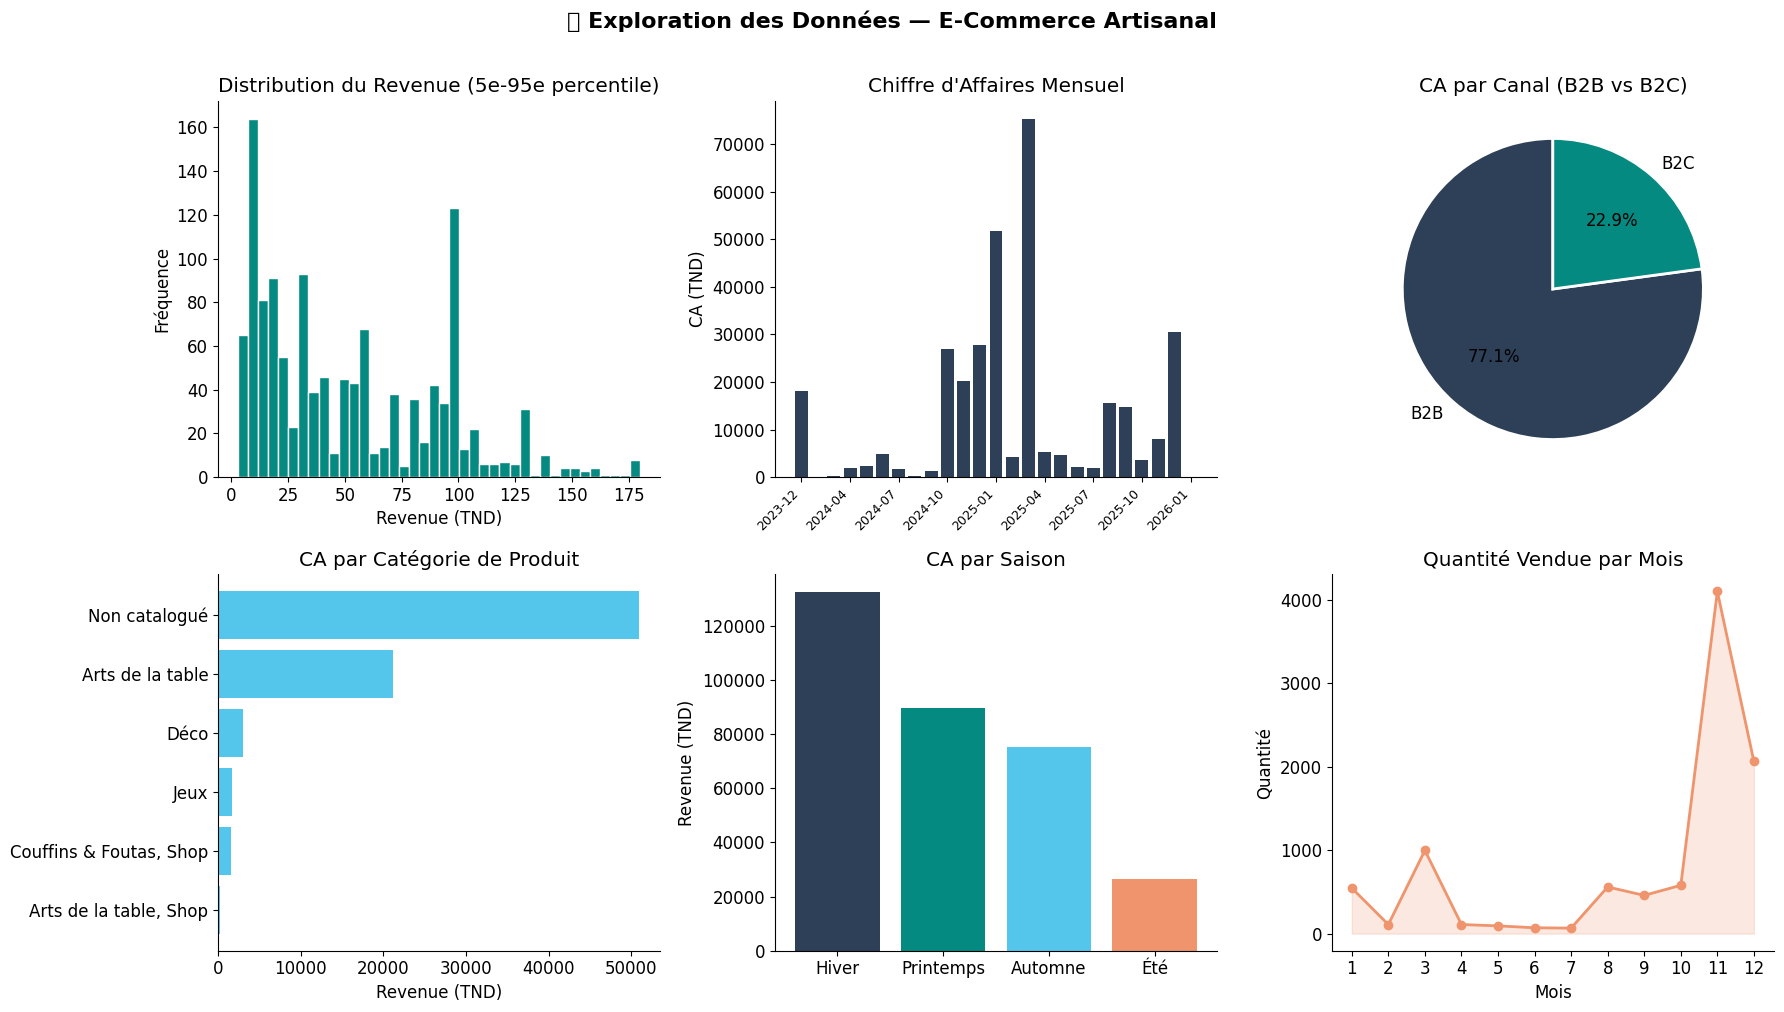

✅ Graphique sauvegardé : exploration_data.png


In [ ]:
# ── Visualisations exploratoires ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Exploration des Données — E-Commerce Artisanal', fontsize=16, fontweight='bold', y=1.01)

# 1. Distribution du revenue
rev_filtered = df[df['revenue'].between(df['revenue'].quantile(0.05), df['revenue'].quantile(0.95))]
axes[0,0].hist(rev_filtered['revenue'], bins=40, color=PALETTE[1], edgecolor='white')
axes[0,0].set_title('Distribution du Revenue (5e-95e percentile)')
axes[0,0].set_xlabel('Revenue (TND)')
axes[0,0].set_ylabel('Fréquence')

# 2. CA mensuel
ca_mensuel = df.groupby(['annee','mois'])['revenue'].sum().reset_index()
ca_mensuel['periode'] = ca_mensuel['annee'].astype(str) + '-' + ca_mensuel['mois'].astype(str).str.zfill(2)
ca_mensuel = ca_mensuel.sort_values('periode')
axes[0,1].bar(range(len(ca_mensuel)), ca_mensuel['revenue'], color=PALETTE[0])
axes[0,1].set_xticks(range(0, len(ca_mensuel), 3))
axes[0,1].set_xticklabels(ca_mensuel['periode'].iloc[::3], rotation=45, ha='right', fontsize=9)
axes[0,1].set_title('Chiffre d\'Affaires Mensuel')
axes[0,1].set_ylabel('CA (TND)')

# 3. Répartition B2B / B2C
canal_ca = df.groupby('type_canal')['revenue'].sum()
axes[0,2].pie(canal_ca.values, labels=canal_ca.index, autopct='%1.1f%%',
              colors=[PALETTE[0], PALETTE[1]], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,2].set_title('CA par Canal (B2B vs B2C)')

# 4. Top catégories produits
cat_ca = df.groupby('Categorie')['revenue'].sum().sort_values(ascending=True).tail(6)
axes[1,0].barh(cat_ca.index, cat_ca.values, color=PALETTE[2])
axes[1,0].set_title('CA par Catégorie de Produit')
axes[1,0].set_xlabel('Revenue (TND)')

# 5. Ventes par saison
saison_ca = df.groupby('saison')['revenue'].sum().sort_values(ascending=False)
axes[1,1].bar(saison_ca.index, saison_ca.values,
              color=[PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]])
axes[1,1].set_title('CA par Saison')
axes[1,1].set_ylabel('Revenue (TND)')

# 6. Quantité vendue par mois
qty_mois = df.groupby('mois')['quantite'].sum()
axes[1,2].plot(qty_mois.index, qty_mois.values, marker='o', color=PALETTE[3], linewidth=2)
axes[1,2].fill_between(qty_mois.index, qty_mois.values, alpha=0.2, color=PALETTE[3])
axes[1,2].set_title('Quantité Vendue par Mois')
axes[1,2].set_xlabel('Mois')
axes[1,2].set_ylabel('Quantité')
axes[1,2].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('exploration_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : exploration_data.png")

---
# 🛠️ SECTION 2 — Data Preparation & Feature Engineering

In [ ]:
# ── 2.1 Nettoyage ─────────────────────────────────────────────────────────────
print("🔍 Valeurs manquantes avant nettoyage :")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Supprimer les lignes sans client identifié
df_clean = df.dropna(subset=['client_key','date_complete','revenue']).copy()

# Corriger les revenues négatifs (retours / avoirs)
df_clean = df_clean[df_clean['revenue'] >= 0].copy()

# Imputer les catégories manquantes
df_clean['Categorie'] = df_clean['Categorie'].fillna('Non catalogué')
df_clean['type_canal'] = df_clean['type_canal'].fillna('B2C')
df_clean['saison'] = df_clean['saison'].fillna('Inconnu')
df_clean['est_ramadan'] = df_clean['est_ramadan'].fillna(False)
df_clean['est_weekend'] = df_clean['est_weekend'].fillna(False)

print(f"\n✅ Dataset nettoyé : {len(df_clean):,} lignes ({len(df)-len(df_clean):,} supprimées)")

🔍 Valeurs manquantes avant nettoyage :
reclamation_key     1386
Client_key           506
Type_client          506
Gouvernorat          640
Secteur_Activite     506
Mode_Paiement        506
Produit_key         1011
Categorie           1011
Matiere             1011
En_Stock            1011
Publie_Web          1011
dtype: int64

✅ Dataset nettoyé : 1,383 lignes (3 supprimées)


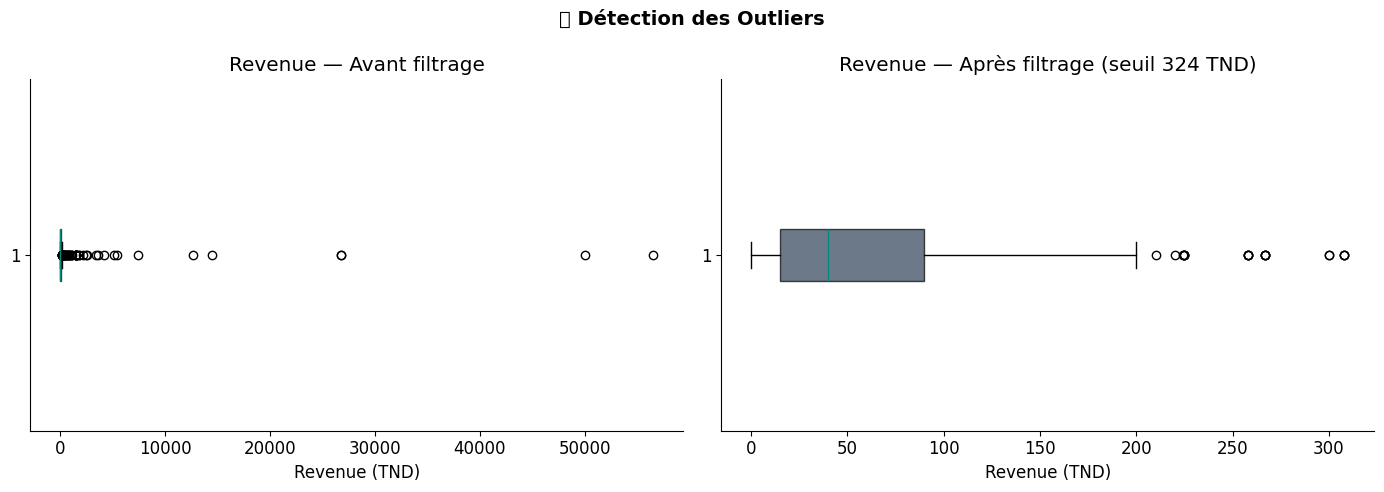


📊 IQR : Q1=16.0, Q3=93.0, IQR=77.0
📊 Seuil outlier (3×IQR) : 323.8 TND
✅ Lignes conservées : 1,342 / 1,383


In [ ]:
# ── 2.2 Détection des outliers ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔍 Détection des Outliers', fontsize=14, fontweight='bold')

axes[0].boxplot(df_clean['revenue'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[1], alpha=0.7))
axes[0].set_title('Revenue — Avant filtrage')
axes[0].set_xlabel('Revenue (TND)')

# IQR method
Q1 = df_clean['revenue'].quantile(0.25)
Q3 = df_clean['revenue'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR  # seuil conservateur (3×IQR) pour conserver les grosses commandes B2B
df_ml = df_clean[df_clean['revenue'] <= upper].copy()

axes[1].boxplot(df_ml['revenue'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.7))
axes[1].set_title(f'Revenue — Après filtrage (seuil {upper:,.0f} TND)')
axes[1].set_xlabel('Revenue (TND)')

plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 IQR : Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
print(f"📊 Seuil outlier (3×IQR) : {upper:,.1f} TND")
print(f"✅ Lignes conservées : {len(df_ml):,} / {len(df_clean):,}")

In [ ]:
# ── 2.3 Feature Engineering RFM ──────────────────────────────────────────────
reference_date = df_ml['date_complete'].max() + pd.Timedelta(days=1)

rfm = df_ml.groupby('client_key').agg(
    Recency   = ('date_complete', lambda x: (reference_date - x.max()).days),
    Frequency = ('vente_key',    'count'),
    Monetary  = ('revenue',      'sum')
).reset_index()

# Features supplémentaires par client
extra = df_ml.groupby('client_key').agg(
    panier_moyen         = ('revenue',   'mean'),
    nb_categories        = ('Categorie', 'nunique'),
    est_weekend_ratio    = ('est_weekend', 'mean'),
    est_ramadan_acheteur = ('est_ramadan', 'max'),
    type_canal_mode      = ('type_canal',  lambda x: x.mode()[0] if len(x.mode()) > 0 else 'B2C')
).reset_index()

rfm = rfm.merge(extra, on='client_key', how='left')

# Score RFM (1-5 par quintile) — robuste si peu de valeurs uniques
def safe_qcut(series, q, labels):
    try:
        return pd.qcut(series, q=q, labels=labels, duplicates='drop').astype(int)
    except ValueError:
        # Fallback : rank-based si trop peu de valeurs uniques
        return pd.cut(series.rank(method='first'), bins=q,
                      labels=labels, include_lowest=True).astype(int)

rfm['R_score'] = safe_qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_score'] = safe_qcut(rfm['Frequency'], q=5, labels=[1,2,3,4,5])
rfm['M_score'] = safe_qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segmentation manuelle basée sur RFM
def segment_client(row):
    if row['RFM_score'] >= 13:
        return 'Champions'
    elif row['RFM_score'] >= 10:
        return 'Fidèles'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'Nouveaux'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'À risque'
    elif row['RFM_score'] <= 6:
        return 'Perdus'
    else:
        return 'Potentiels'

rfm['Segment_RFM'] = rfm.apply(segment_client, axis=1)

print(f"✅ Matrice RFM construite : {rfm.shape[0]} clients")
print("\n📊 Distribution des segments :")
print(rfm['Segment_RFM'].value_counts())
display(rfm.head())

✅ Matrice RFM construite : 435 clients

📊 Distribution des segments :
Segment_RFM
Fidèles       130
Potentiels     99
À risque       78
Nouveaux       59
Champions      39
Perdus         30
Name: count, dtype: int64


,client_key,Recency,Frequency,Monetary,panier_moyen,nb_categories,est_weekend_ratio,est_ramadan_acheteur,type_canal_mode,R_score,F_score,M_score,RFM_score,Segment_RFM
0,0,92,505,24137.00,47.796040,2,0.29703,False,B2C,4,5,5,14,Champions
1,4,19,1,300.00,300.000000,1,0.00000,False,B2B,5,1,5,11,Fidèles
2,9,267,4,224.34,56.085000,1,0.00000,False,B2B,2,5,5,12,Fidèles
3,17,43,53,5919.60,111.690566,1,0.09434,True,B2B,5,5,5,15,Champions
4,70,22,5,605.00,121.000000,1,0.00000,False,B2B,5,5,5,15,Champions


In [ ]:
# ── 2.4 Construction du dataset ML final ─────────────────────────────────────
# Encodage des variables catégorielles
le = LabelEncoder()

df_ml['type_canal_enc']      = le.fit_transform(df_ml['type_canal'].astype(str))
df_ml['saison_enc']          = le.fit_transform(df_ml['saison'].astype(str))
df_ml['Categorie_enc']       = le.fit_transform(df_ml['Categorie'].astype(str))
df_ml['est_weekend_int']     = df_ml['est_weekend'].astype(int)
df_ml['est_ramadan_int']     = df_ml['est_ramadan'].astype(int)

# ── Cible 1 : Classification — Client "haute valeur" ─────────────────────────
seuil_hv = df_ml.groupby('client_key')['revenue'].sum().median()
ca_client = df_ml.groupby('client_key')['revenue'].sum()
rfm['is_high_value'] = (ca_client.reindex(rfm['client_key']).values >= seuil_hv).astype(int)

# ── Cible 2 : Classification — Churn (inactif > 90 jours) ────────────────────
rfm['is_churned'] = (rfm['Recency'] > 90).astype(int)

print(f"\n📊 Seuil 'haute valeur' : {seuil_hv:,.2f} TND")
print(f"   Clients haute valeur : {rfm['is_high_value'].sum()} / {len(rfm)}")
print(f"   Clients churned (>90j): {rfm['is_churned'].sum()} / {len(rfm)}")


📊 Seuil 'haute valeur' : 58.00 TND
   Clients haute valeur : 225 / 435
   Clients churned (>90j): 312 / 435


---
# 🎯 SECTION 3 — Classification

In [ ]:
# ── 3.1 Préparation features classification ───────────────────────────────────
rfm_enc = rfm.copy()
rfm_enc['type_canal_enc'] = le.fit_transform(rfm_enc['type_canal_mode'].astype(str))

FEATURES_CLF = ['Recency', 'Frequency', 'Monetary', 'panier_moyen',
                 'nb_categories', 'est_weekend_ratio', 'R_score', 'F_score', 'M_score']

X_clf = rfm_enc[FEATURES_CLF].fillna(0)
y_clf = rfm_enc['is_high_value']  # cible principale

# Scaling
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# SMOTE si déséquilibre
if y_clf.value_counts(normalize=True).min() < 0.3:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"⚖️  SMOTE appliqué — nouveau train : {len(X_train)} échantillons")

print(f"\n✅ Train : {len(X_train)} | Test : {len(X_test)}")
print(f"   Classes — 0: {y_clf.sum()} haute valeur | 1: {(y_clf==0).sum()} standard")


✅ Train : 348 | Test : 87
   Classes — 0: 225 haute valeur | 1: 210 standard


In [ ]:
# ── 3.2 Entraînement et comparaison des modèles ────────────────────────────────
models_clf = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results_clf = []
fitted_models = {}

for name, model in models_clf.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else y_pred

    cv_scores = cross_val_score(model, X_clf_scaled, y_clf, cv=5, scoring='f1')

    results_clf.append({
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
        'CV F1 mean': round(cv_scores.mean(), 4),
        'CV F1 std' : round(cv_scores.std(), 4),
    })
    fitted_models[name] = (model, y_pred, y_proba)
    print(f"  ✔ {name} — Accuracy={accuracy_score(y_test,y_pred):.3f} | F1={f1_score(y_test,y_pred,zero_division=0):.3f}")

results_clf_df = pd.DataFrame(results_clf).sort_values('F1-Score', ascending=False)
print("\n📊 Tableau comparatif :")
display(results_clf_df)

  ✔ Logistic Regression — Accuracy=0.954 | F1=0.957
  ✔ Decision Tree — Accuracy=1.000 | F1=1.000
  ✔ Random Forest — Accuracy=1.000 | F1=1.000
  ✔ Gradient Boosting — Accuracy=1.000 | F1=1.000

📊 Tableau comparatif :


,Modèle,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 mean,CV F1 std
1,Decision Tree,1.000,1.0000,1.0000,1.0000,1.0000,0.9957,0.0087
2,Random Forest,1.000,1.0000,1.0000,1.0000,1.0000,0.9957,0.0087
3,Gradient Boosting,1.000,1.0000,1.0000,1.0000,1.0000,0.9957,0.0087
0,Logistic Regression,0.954,0.9362,0.9778,0.9565,0.9921,0.9640,0.0202


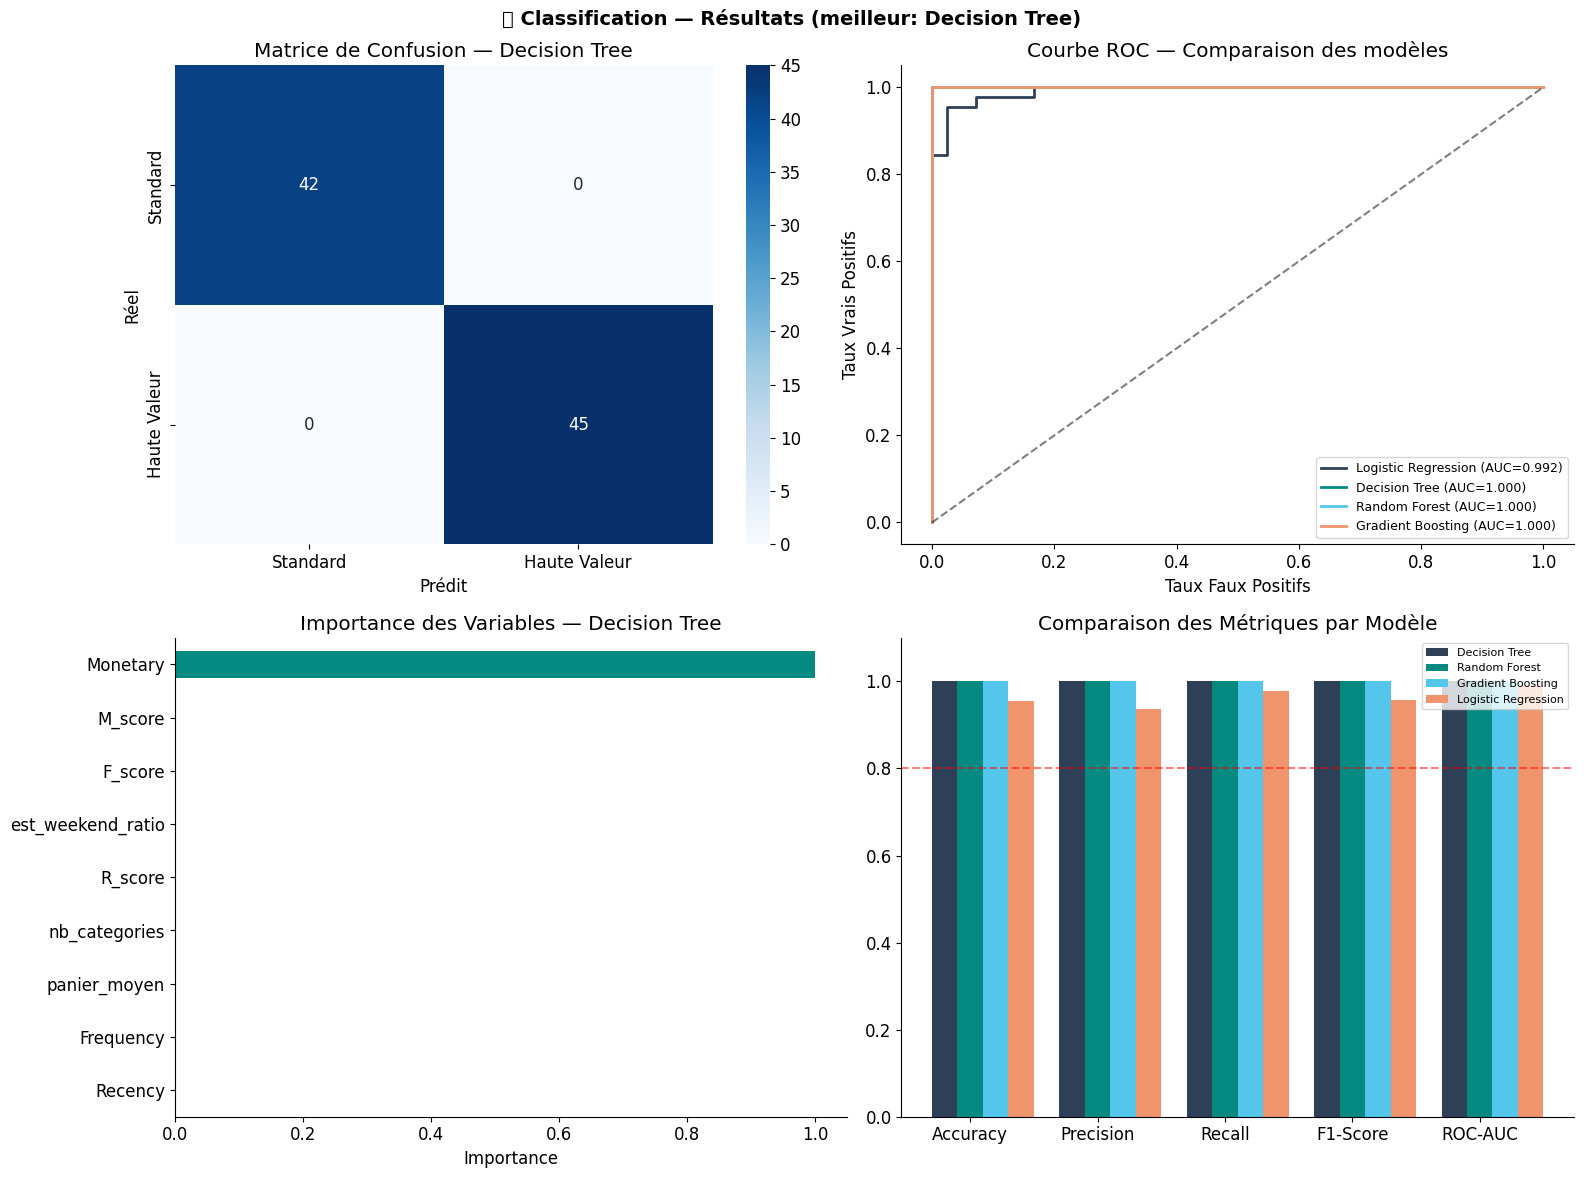


✅ Graphiques sauvegardés : classification_results.png

📝 Rapport de classification — Decision Tree:
              precision    recall  f1-score   support

    Standard       1.00      1.00      1.00        42
Haute Valeur       1.00      1.00      1.00        45

    accuracy                           1.00        87
   macro avg       1.00      1.00      1.00        87
weighted avg       1.00      1.00      1.00        87



In [ ]:
# ── 3.3 Visualisations Classification ─────────────────────────────────────────
best_name = results_clf_df.iloc[0]['Modèle']
best_model, best_pred, best_proba = fitted_models[best_name]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'🎯 Classification — Résultats (meilleur: {best_name})',
             fontsize=14, fontweight='bold')

# 1. Matrice de confusion
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Standard','Haute Valeur'],
            yticklabels=['Standard','Haute Valeur'])
axes[0,0].set_title(f'Matrice de Confusion — {best_name}')
axes[0,0].set_xlabel('Prédit')
axes[0,0].set_ylabel('Réel')

# 2. Courbe ROC multi-modèles
for name, (model, _, proba) in fitted_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0,1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[0,1].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[0,1].set_title('Courbe ROC — Comparaison des modèles')
axes[0,1].set_xlabel('Taux Faux Positifs')
axes[0,1].set_ylabel('Taux Vrais Positifs')
axes[0,1].legend(fontsize=9)

# 3. Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES_CLF).sort_values()
    importances.plot(kind='barh', ax=axes[1,0], color=PALETTE[1])
    axes[1,0].set_title(f'Importance des Variables — {best_name}')
    axes[1,0].set_xlabel('Importance')

# 4. Comparaison métriques
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
for i, (_, row) in enumerate(results_clf_df.iterrows()):
    axes[1,1].bar(x + i*width, [row[m] for m in metrics], width, label=row['Modèle'])
axes[1,1].set_xticks(x + width)
axes[1,1].set_xticklabels(metrics)
axes[1,1].set_ylim(0, 1.1)
axes[1,1].set_title('Comparaison des Métriques par Modèle')
axes[1,1].legend(fontsize=8)
axes[1,1].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Seuil 80%')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graphiques sauvegardés : classification_results.png")

print(f"\n📝 Rapport de classification — {best_name}:")
print(classification_report(y_test, best_pred, target_names=['Standard','Haute Valeur']))

In [ ]:
# ── 3.4 Prédictions sur tous les clients ──────────────────────────────────────
X_all = scaler_clf.transform(rfm_enc[FEATURES_CLF].fillna(0))
rfm_enc['pred_high_value']    = best_model.predict(X_all)
rfm_enc['proba_high_value']   = best_model.predict_proba(X_all)[:,1]
rfm_enc['pred_is_churned']    = (rfm_enc['Recency'] > 90).astype(int)
rfm_enc['risque_churn_label'] = rfm_enc['pred_is_churned'].map({1:'⚠️ À risque', 0:'✅ Actif'})

print("✅ Prédictions générées pour tous les clients")
display(rfm_enc[['client_key','Recency','Frequency','Monetary','Segment_RFM',
                  'pred_high_value','proba_high_value','risque_churn_label']].head(10))

✅ Prédictions générées pour tous les clients


,client_key,Recency,Frequency,Monetary,Segment_RFM,pred_high_value,proba_high_value,risque_churn_label
0,0,92,505,24137.00,Champions,1,1.0,⚠️ À risque
1,4,19,1,300.00,Fidèles,1,1.0,✅ Actif
2,9,267,4,224.34,Fidèles,1,1.0,⚠️ À risque
3,17,43,53,5919.60,Champions,1,1.0,✅ Actif
4,70,22,5,605.00,Champions,1,1.0,✅ Actif
5,75,43,22,1871.00,Champions,1,1.0,✅ Actif
6,97,24,1,20.00,Nouveaux,0,0.0,✅ Actif
7,99,263,1,150.00,Potentiels,1,1.0,⚠️ À risque
8,108,47,3,586.00,Champions,1,1.0,✅ Actif
9,113,747,1,0.00,Perdus,0,0.0,⚠️ À risque


---
# 📈 SECTION 4 — Régression (Prévision du Revenue)

In [ ]:
# ── 4.1 Préparation dataset régression ────────────────────────────────────────
FEATURES_REG = ['quantite', 'mois', 'trimestre', 'type_canal_enc',
                 'saison_enc', 'Categorie_enc', 'est_weekend_int', 'est_ramadan_int',
                 'montant_remise']

df_reg = df_ml[FEATURES_REG + ['revenue']].dropna()

X_reg = df_reg[FEATURES_REG]
y_reg = df_reg['revenue']

scaler_reg = RobustScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

print(f"✅ Dataset régression : {len(df_reg):,} lignes | {len(FEATURES_REG)} features")

✅ Dataset régression : 1,342 lignes | 9 features


In [ ]:
# ── 4.2 Entraînement modèles régression ───────────────────────────────────────
models_reg = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Random Forest Reg.'  : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results_reg = []
fitted_reg  = {}

for name, model in models_reg.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    results_reg.append({'Modèle': name, 'RMSE': round(rmse, 2),
                        'MAE': round(mae, 2), 'R²': round(r2, 4)})
    fitted_reg[name] = (model, y_pred)
    print(f"  ✔ {name} — RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.4f}")

results_reg_df = pd.DataFrame(results_reg).sort_values('R²', ascending=False)
print("\n📊 Tableau comparatif Régression :")
display(results_reg_df)

  ✔ Linear Regression — RMSE=49.61 | MAE=36.42 | R²=0.0770
  ✔ Ridge Regression — RMSE=49.62 | MAE=36.43 | R²=0.0766
  ✔ Random Forest Reg. — RMSE=46.22 | MAE=32.97 | R²=0.1985

📊 Tableau comparatif Régression :


,Modèle,RMSE,MAE,R²
2,Random Forest Reg.,46.22,32.97,0.1985
0,Linear Regression,49.61,36.42,0.0770
1,Ridge Regression,49.62,36.43,0.0766


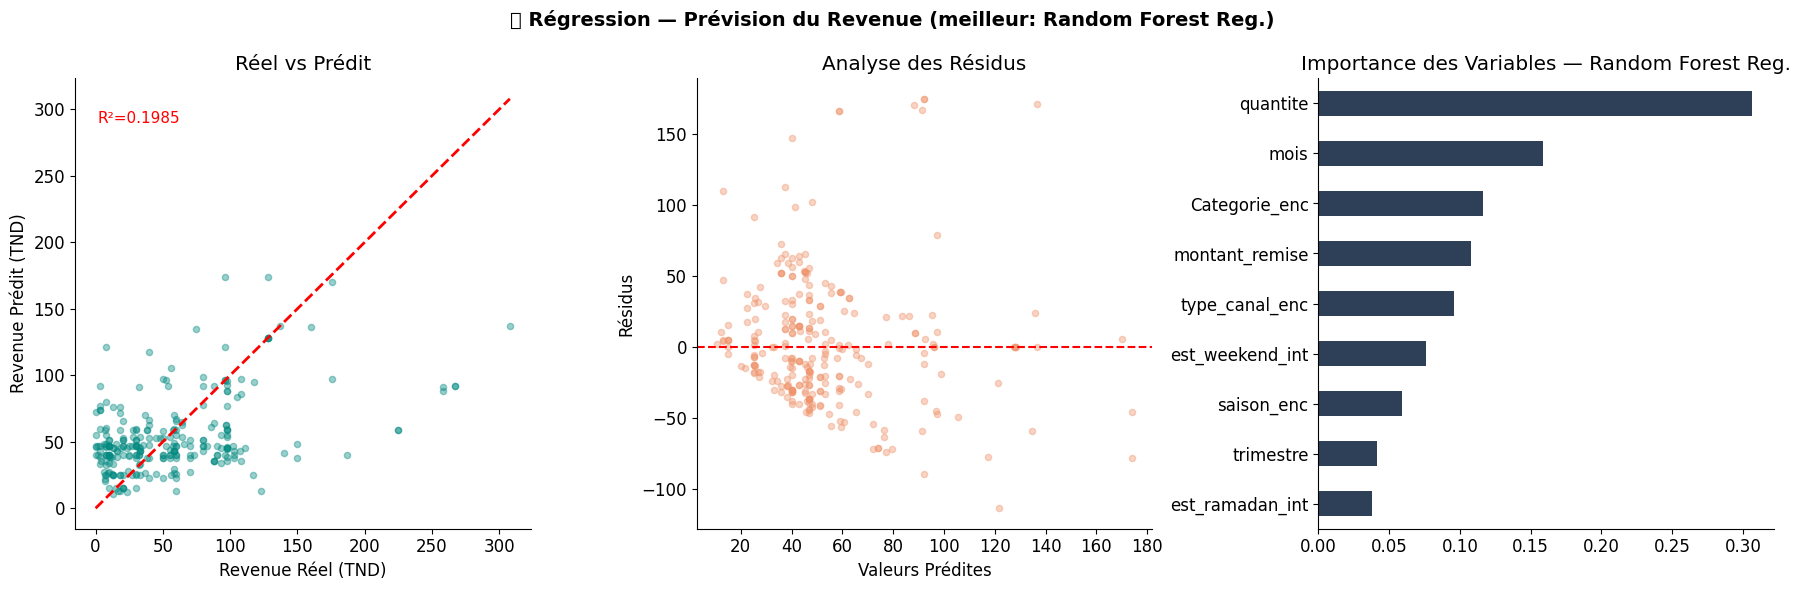

✅ Sauvegardé : regression_results.png


In [ ]:
# ── 4.3 Visualisations Régression ─────────────────────────────────────────────
best_reg_name = results_reg_df.iloc[0]['Modèle']
best_reg_model, best_reg_pred = fitted_reg[best_reg_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'📈 Régression — Prévision du Revenue (meilleur: {best_reg_name})',
             fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
axes[0].scatter(y_te, best_reg_pred, alpha=0.4, color=PALETTE[1], s=20)
lim = max(y_te.max(), best_reg_pred.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=2)
axes[0].set_title('Réel vs Prédit')
axes[0].set_xlabel('Revenue Réel (TND)')
axes[0].set_ylabel('Revenue Prédit (TND)')
axes[0].text(0.05, 0.9, f"R²={results_reg_df.iloc[0]['R²']:.4f}",
             transform=axes[0].transAxes, fontsize=11, color='red')

# 2. Résidus
residuals = y_te - best_reg_pred
axes[1].scatter(best_reg_pred, residuals, alpha=0.4, color=PALETTE[3], s=20)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Analyse des Résidus')
axes[1].set_xlabel('Valeurs Prédites')
axes[1].set_ylabel('Résidus')

# 3. Feature importance
if hasattr(best_reg_model, 'feature_importances_'):
    imp = pd.Series(best_reg_model.feature_importances_, index=FEATURES_REG).sort_values()
    imp.plot(kind='barh', ax=axes[2], color=PALETTE[0])
    axes[2].set_title(f'Importance des Variables — {best_reg_name}')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : regression_results.png")

---
# 👥 SECTION 5 — Clustering (Segmentation Clients RFM)

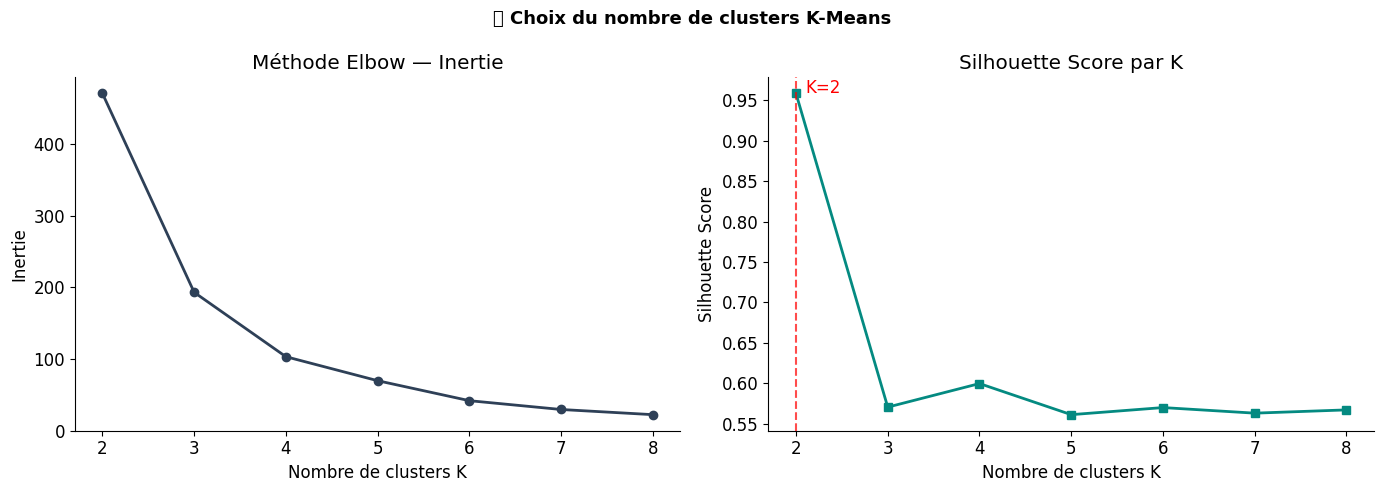

✅ Meilleur K selon Silhouette : K=2


In [ ]:
# ── 5.1 Préparation RFM pour clustering ───────────────────────────────────────
rfm_cluster = rfm[['Recency','Frequency','Monetary']].copy()

scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm_cluster)

# ── Elbow Method ─────────────────────────────────────────────────────────────
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔍 Choix du nombre de clusters K-Means', fontsize=13, fontweight='bold')

axes[0].plot(K_range, inertias, marker='o', color=PALETTE[0], linewidth=2)
axes[0].set_title('Méthode Elbow — Inertie')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')

axes[1].plot(K_range, silhouette_scores, marker='s', color=PALETTE[1], linewidth=2)
axes[1].set_title('Silhouette Score par K')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.7)
axes[1].text(best_k+0.1, max(silhouette_scores), f'K={best_k}', color='red')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Meilleur K selon Silhouette : K={best_k}")

In [ ]:
# ── 5.2 KMeans final ──────────────────────────────────────────────────────────
K_FINAL = best_k
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans_final.fit_predict(rfm_scaled)

# Labels lisibles
cluster_stats = rfm.groupby('Cluster_KMeans')[['Recency','Frequency','Monetary']].mean()
print("📊 Profil moyen par cluster :")
display(cluster_stats)

# Attribution labels métier automatique
cluster_stats_sorted = cluster_stats.sort_values('Monetary', ascending=False)
labels_map = {}
label_names = ['🥇 VIP / Champions', '⭐ Fidèles', '🔵 Potentiels', '🟡 Dormants', '⬜ Inactifs']
for i, idx in enumerate(cluster_stats_sorted.index):
    labels_map[idx] = label_names[i] if i < len(label_names) else f'Cluster {idx}'

rfm['Cluster_Label'] = rfm['Cluster_KMeans'].map(labels_map)

sil = silhouette_score(rfm_scaled, rfm['Cluster_KMeans'])
print(f"\n✅ Silhouette Score final : {sil:.4f}")
print("\n📊 Distribution des segments :")
print(rfm['Cluster_Label'].value_counts())

📊 Profil moyen par cluster :


,Recency,Frequency,Monetary
Cluster_KMeans,,,
0,196.223502,1.928571,112.372673
1,92.000000,505.000000,24137.000000



✅ Silhouette Score final : 0.9584

📊 Distribution des segments :
Cluster_Label
⭐ Fidèles            434
🥇 VIP / Champions      1
Name: count, dtype: int64


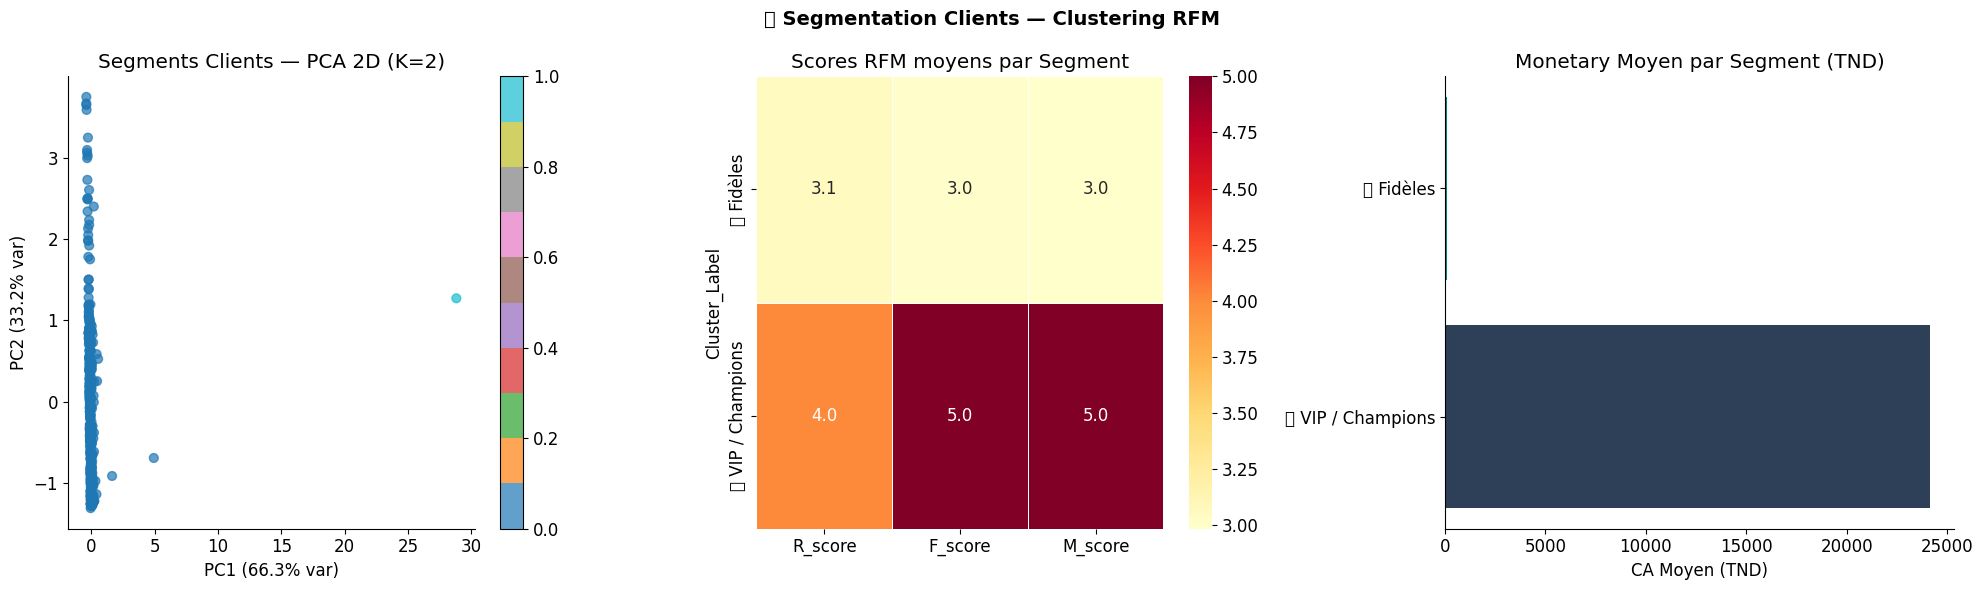

✅ Sauvegardé : clustering_results.png


In [ ]:
# ── 5.3 Visualisations Clustering ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(rfm_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('👥 Segmentation Clients — Clustering RFM', fontsize=14, fontweight='bold')

# 1. PCA 2D
scatter = axes[0].scatter(pca_result[:,0], pca_result[:,1],
                           c=rfm['Cluster_KMeans'], cmap='tab10', alpha=0.7, s=40)
axes[0].set_title(f'Segments Clients — PCA 2D (K={K_FINAL})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter, ax=axes[0])

# 2. Heatmap RFM par cluster
heatmap_data = rfm.groupby('Cluster_Label')[['R_score','F_score','M_score']].mean()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Scores RFM moyens par Segment')

# 3. CA moyen par segment
ca_segment = rfm.groupby('Cluster_Label')['Monetary'].mean().sort_values(ascending=False)
axes[2].barh(ca_segment.index, ca_segment.values,
             color=[PALETTE[i%len(PALETTE)] for i in range(len(ca_segment))])
axes[2].set_title('Monetary Moyen par Segment (TND)')
axes[2].set_xlabel('CA Moyen (TND)')

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : clustering_results.png")

---
# 📅 SECTION 6 — Time Series (Forecasting CA avec Prophet)

✅ Série temporelle : 254 jours
   De : 2024-02-20 → 2026-01-02
   Revenue min : 0.00 TND
   Revenue max : 1707.80 TND


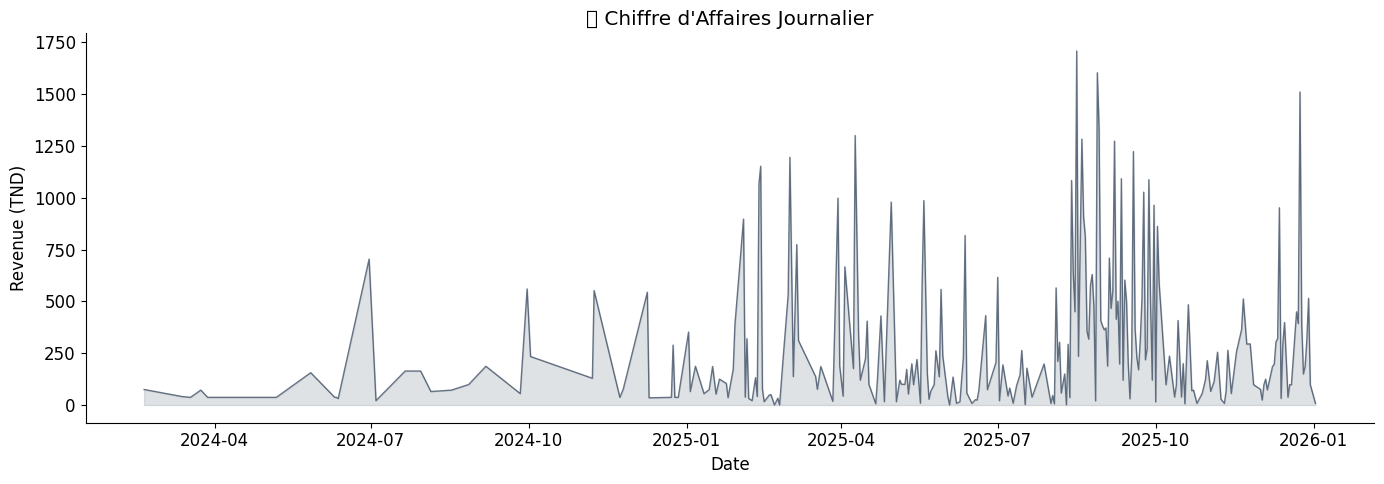

In [ ]:
# ── 6.1 Préparation série temporelle ─────────────────────────────────────────
ts_df = df_ml.groupby('date_complete')['revenue'].sum().reset_index()
ts_df.columns = ['ds', 'y']
ts_df = ts_df.sort_values('ds').reset_index(drop=True)

# Garder seulement les données 2024-2025 (plus dense)
ts_df = ts_df[ts_df['ds'] >= '2024-01-01'].copy()

print(f"✅ Série temporelle : {len(ts_df)} jours")
print(f"   De : {ts_df['ds'].min().date()} → {ts_df['ds'].max().date()}")
print(f"   Revenue min : {ts_df['y'].min():.2f} TND")
print(f"   Revenue max : {ts_df['y'].max():.2f} TND")

# Visualisation série brute
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_df['ds'], ts_df['y'], color=PALETTE[0], linewidth=1, alpha=0.7)
ax.fill_between(ts_df['ds'], ts_df['y'], alpha=0.15, color=PALETTE[0])
ax.set_title('📅 Chiffre d\'Affaires Journalier')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (TND)')
plt.tight_layout()
plt.savefig('serie_temporelle_brute.png', dpi=150)
plt.show()

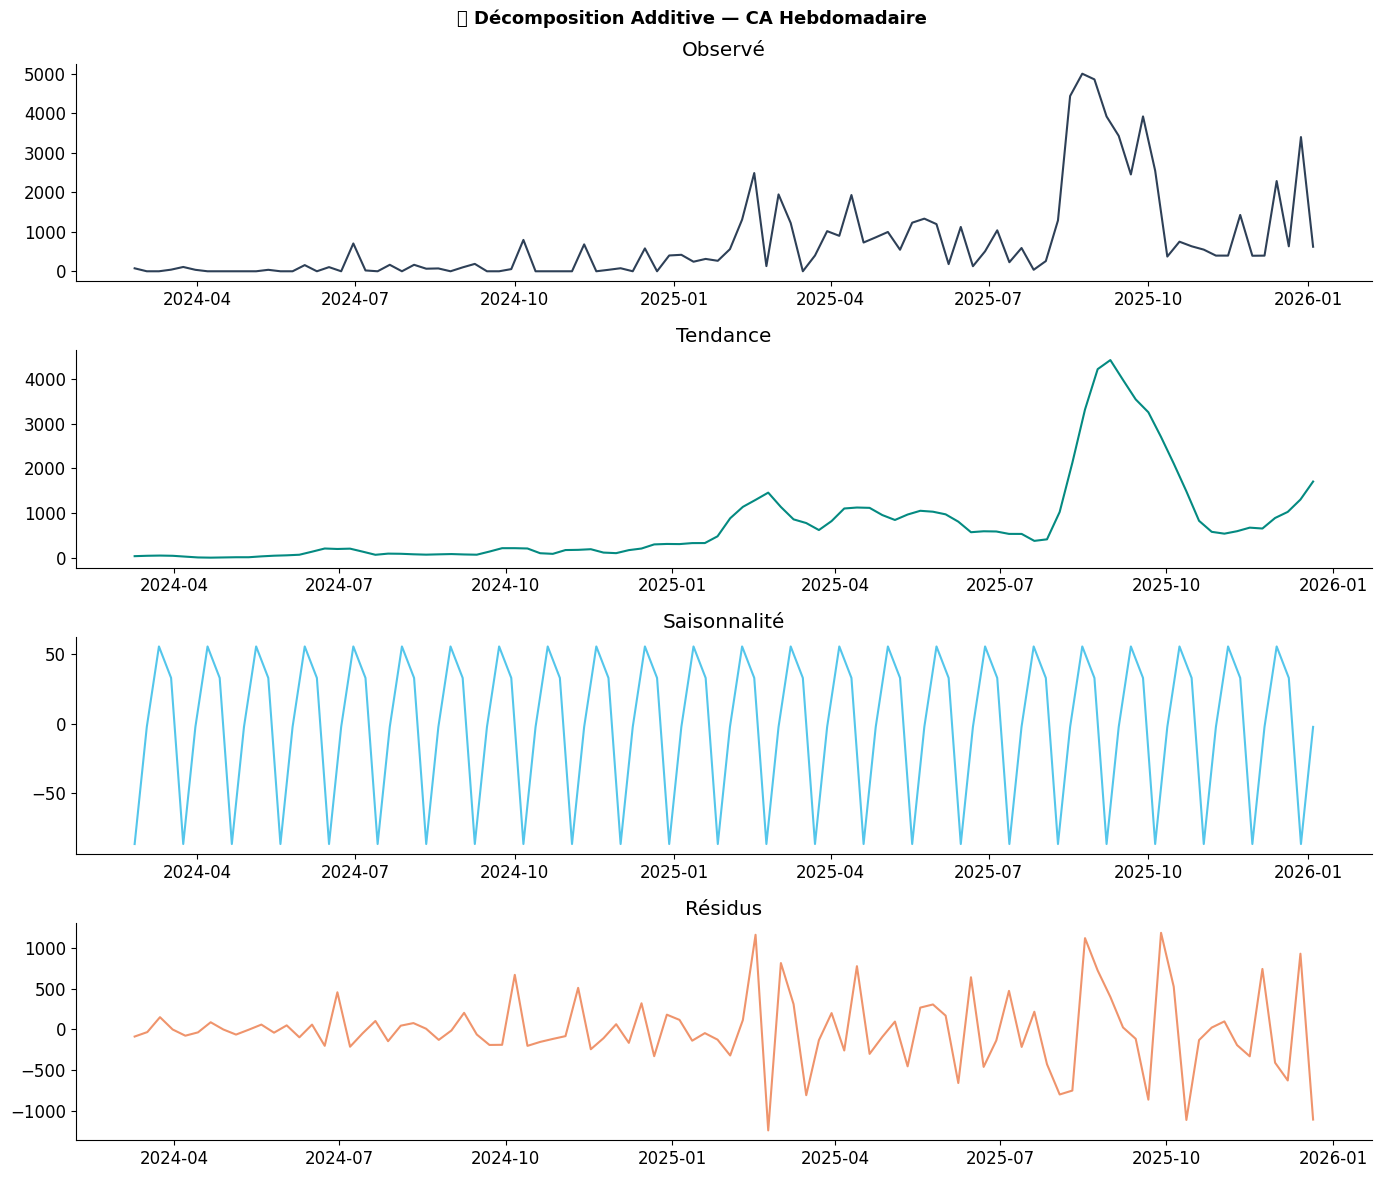

In [ ]:
# ── 6.2 Décomposition de la série ─────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

# Rééchantillonnage hebdomadaire pour décomposition
ts_weekly = ts_df.set_index('ds')['y'].resample('W').sum()

if len(ts_weekly) > 10:
    decomp = seasonal_decompose(ts_weekly, model='additive', period=4)
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    fig.suptitle('📊 Décomposition Additive — CA Hebdomadaire', fontsize=13, fontweight='bold')

    axes[0].plot(decomp.observed,  color=PALETTE[0]); axes[0].set_title('Observé')
    axes[1].plot(decomp.trend,     color=PALETTE[1]); axes[1].set_title('Tendance')
    axes[2].plot(decomp.seasonal,  color=PALETTE[2]); axes[2].set_title('Saisonnalité')
    axes[3].plot(decomp.resid,     color=PALETTE[3]); axes[3].set_title('Résidus')

    for ax in axes: ax.set_xlabel('')
    plt.tight_layout()
    plt.savefig('decomposition_ts.png', dpi=150)
    plt.show()
else:
    print("ℹ️  Données insuffisantes pour la décomposition hebdomadaire")

In [ ]:
# ── 6.3 Modèle Prophet ────────────────────────────────────────────────────────
prophet_model = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,
    interval_width=0.90
)

# Ajout d'une saisonnalité Ramadan (contextuel Tunisie)
prophet_model.add_seasonality(name='mensuel', period=30.5, fourier_order=5)

prophet_model.fit(ts_df)

# Prévision 60 jours
future = prophet_model.make_future_dataframe(periods=60)
forecast = prophet_model.predict(future)

print("✅ Modèle Prophet entraîné")
print(f"   Prévision jusqu'au : {forecast['ds'].max().date()}")
display(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(10))

✅ Modèle Prophet entraîné
   Prévision jusqu'au : 2026-03-03


,ds,yhat,yhat_lower,yhat_upper
304,2026-02-22,482.495365,20.468662,963.137617
305,2026-02-23,433.440901,-68.971961,910.356585
306,2026-02-24,341.339943,-114.471351,828.497419
307,2026-02-25,442.096637,-2.974048,913.578284
308,2026-02-26,536.161488,63.309827,973.797495
309,2026-02-27,462.801492,-15.479217,936.585088
310,2026-02-28,541.417245,56.306716,1009.110116
311,2026-03-01,701.034093,217.635326,1196.209706
312,2026-03-02,604.221528,125.483847,1082.867732
313,2026-03-03,429.591830,-22.702836,877.669224


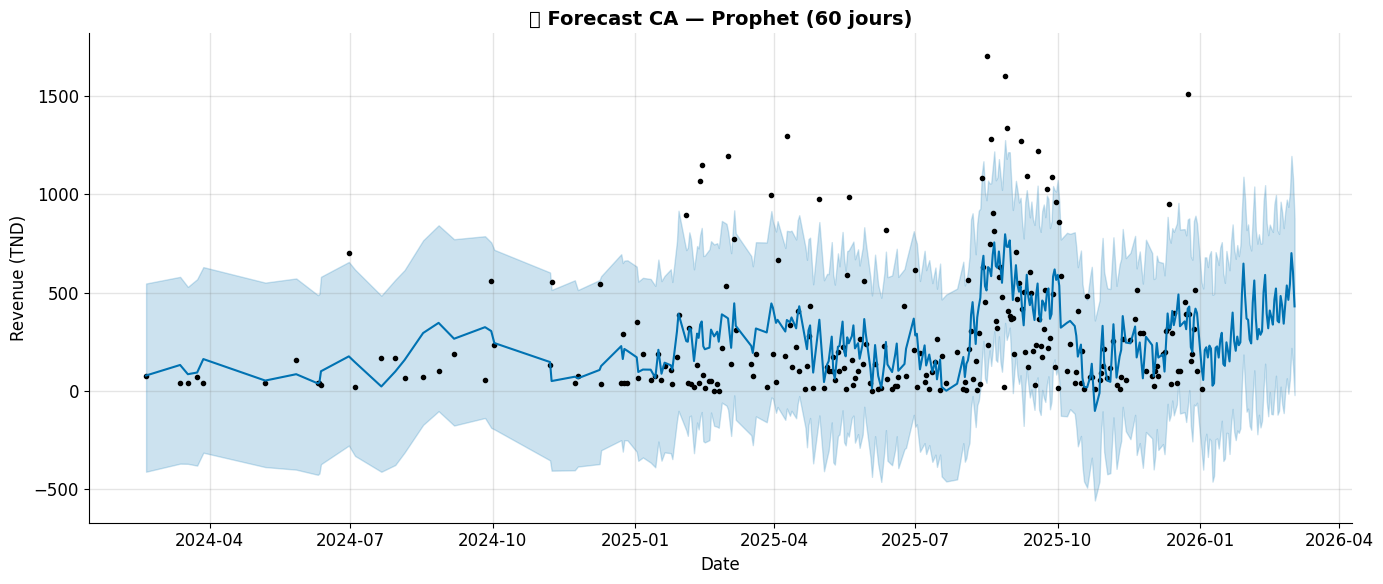

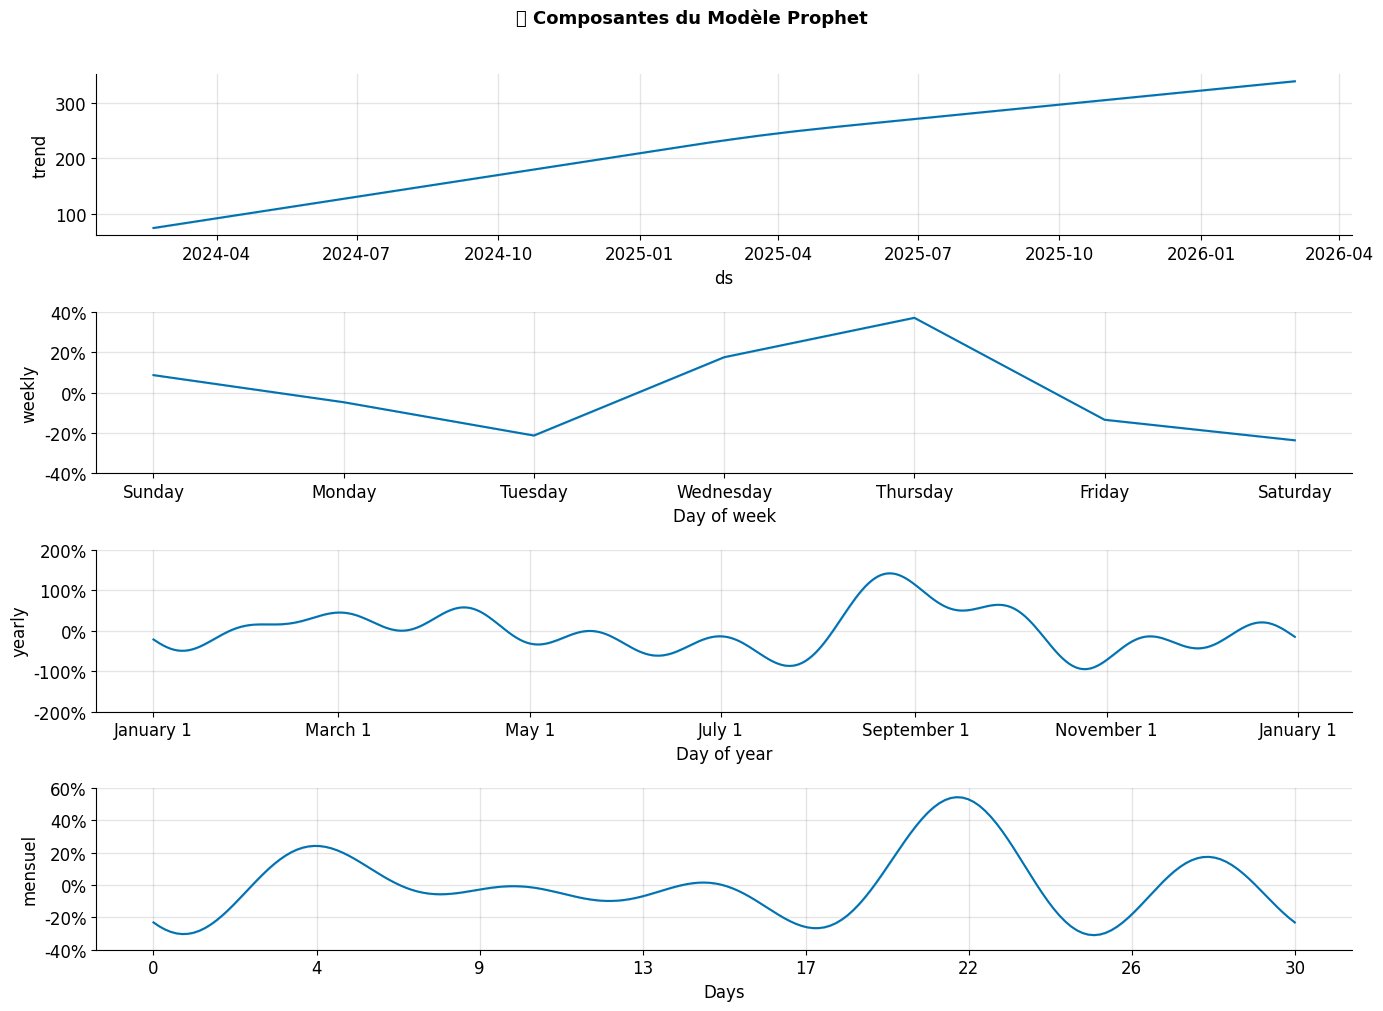

✅ Graphiques Prophet sauvegardés


In [ ]:
# ── 6.4 Visualisations Prophet ────────────────────────────────────────────────
fig = prophet_model.plot(forecast, figsize=(14, 6))
plt.title('📅 Forecast CA — Prophet (60 jours)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (TND)')
plt.tight_layout()
plt.savefig('forecast_prophet.png', dpi=150)
plt.show()

# Composantes
fig2 = prophet_model.plot_components(forecast, figsize=(14, 10))
plt.suptitle('🔍 Composantes du Modèle Prophet', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150)
plt.show()
print("✅ Graphiques Prophet sauvegardés")

In [ ]:
# ── 6.5 Métriques Prophet (cross-validation) ──────────────────────────────────
try:
    df_cv = cross_validation(prophet_model, initial='120 days', period='30 days', horizon='30 days')
    df_perf = performance_metrics(df_cv)
    print("📊 Métriques Prophet (Cross-Validation) :")
    display(df_perf[['horizon','mse','rmse','mae','mape']].head(10))
    print(f"\n   MAPE moyen : {df_perf['mape'].mean()*100:.2f}%")
    print(f"   RMSE moyen : {df_perf['rmse'].mean():.2f} TND")
except Exception as e:
    print(f"ℹ️  Cross-validation Prophet : données insuffisantes ({e})")
    # Métriques sur données existantes
    actual   = ts_df.set_index('ds')['y']
    pred_in  = forecast.set_index('ds').reindex(actual.index)['yhat']
    mask     = pred_in.notna() & actual.notna()
    rmse_p   = np.sqrt(mean_squared_error(actual[mask], pred_in[mask]))
    mae_p    = mean_absolute_error(actual[mask], pred_in[mask])
    mape_p   = np.mean(np.abs((actual[mask] - pred_in[mask]) / (actual[mask] + 1e-9))) * 100
    print(f"   RMSE in-sample : {rmse_p:.2f} TND")
    print(f"   MAE  in-sample : {mae_p:.2f} TND")
    print(f"   MAPE in-sample : {mape_p:.2f}%")

INFO:prophet:Making 18 forecasts with cutoffs between 2024-07-11 00:00:00 and 2025-12-03 00:00:00


  0%|          | 0/18 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 17.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:Skipping MAPE because y close to 0


📊 Métriques Prophet (Cross-Validation) :
ℹ️  Cross-validation Prophet : données insuffisantes ("['mape'] not in index")
   RMSE in-sample : 283.62 TND
   MAE  in-sample : 197.82 TND
   MAPE in-sample : 211340565505.68%


---
# 💾 SECTION 7 — Sauvegarde des Modèles

> **Objectif :** Sauvegarder tous les artefacts entraînés (modèles + scalers) dans des fichiers `.joblib`/`.pkl` pour le déploiement Flask.

| Artefact | Fichier | Description |
|---|---|---|
| Meilleur classifieur | `best_classifier.joblib` | Modèle de classification client (haute valeur) |
| Meilleur régresseur | `best_regressor.joblib` | Modèle de prévision du revenue |
| Modèle Prophet | `prophet_model.pkl` | Modèle de forecasting temporel |
| Modèle KMeans | `kmeans_model.joblib` | Modèle de segmentation RFM |
| Scaler classification | `scaler_clf.joblib` | StandardScaler pour la classification |
| Scaler régression | `scaler_reg.joblib` | RobustScaler pour la régression |

In [ ]:
# ── 7.1 Sauvegarde des Modèles ML & Scalers ──────────────────────────────────
import joblib
import pickle
import os

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Meilleur classifieur ─────────────────────────────────────────────────────
# fitted_models[name] = (model, y_pred, y_proba)  → tuple à 3 éléments
best_clf_name = results_clf_df.iloc[0]['Modèle']
best_clf_model, _, _ = fitted_models[best_clf_name]
clf_path = os.path.join(MODELS_DIR, 'best_classifier.joblib')
joblib.dump(best_clf_model, clf_path)
print(f"✅ Classifieur sauvegardé  : {clf_path}  ({best_clf_name})")

# ── Meilleur régresseur ──────────────────────────────────────────────────────
# fitted_reg[name] = (model, y_pred)  → tuple à 2 éléments
best_reg_name = results_reg_df.iloc[0]['Modèle']
best_reg_model, _ = fitted_reg[best_reg_name]
reg_path = os.path.join(MODELS_DIR, 'best_regressor.joblib')
joblib.dump(best_reg_model, reg_path)
print(f"✅ Régresseur sauvegardé   : {reg_path}  ({best_reg_name})")

# ── Modèle Prophet ───────────────────────────────────────────────────────────
prophet_path = os.path.join(MODELS_DIR, 'prophet_model.pkl')
with open(prophet_path, 'wb') as f:
    pickle.dump(prophet_model, f)
print(f"✅ Prophet sauvegardé      : {prophet_path}")

# ── Modèle KMeans ────────────────────────────────────────────────────────────
kmeans_path = os.path.join(MODELS_DIR, 'kmeans_model.joblib')
joblib.dump(kmeans_final, kmeans_path)
print(f"✅ KMeans sauvegardé       : {kmeans_path}")

# ── Scalers ──────────────────────────────────────────────────────────────────
scaler_clf_path = os.path.join(MODELS_DIR, 'scaler_clf.joblib')
joblib.dump(scaler_clf, scaler_clf_path)
print(f"✅ Scaler CLF sauvegardé   : {scaler_clf_path}  (StandardScaler)")

scaler_reg_path = os.path.join(MODELS_DIR, 'scaler_reg.joblib')
joblib.dump(scaler_reg, scaler_reg_path)
print(f"✅ Scaler REG sauvegardé   : {scaler_reg_path}  (RobustScaler)")

print("\n" + "─" * 60)
print("📦 Récapitulatif des artefacts sauvegardés :")
print("─" * 60)
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   {fname:<35} {size_kb:>8.1f} KB")
print("─" * 60)
print("✅ Tous les artefacts sont prêts pour le déploiement Flask.")

✅ Classifieur sauvegardé  : models/best_classifier.joblib  (Decision Tree)
✅ Régresseur sauvegardé   : models/best_regressor.joblib  (Random Forest Reg.)
✅ Prophet sauvegardé      : models/prophet_model.pkl
✅ KMeans sauvegardé       : models/kmeans_model.joblib
✅ Scaler CLF sauvegardé   : models/scaler_clf.joblib  (StandardScaler)
✅ Scaler REG sauvegardé   : models/scaler_reg.joblib  (RobustScaler)

────────────────────────────────────────────────────────────
📦 Récapitulatif des artefacts sauvegardés :
────────────────────────────────────────────────────────────
   best_classifier.joblib                   1.5 KB
   best_regressor.joblib                 2296.0 KB
   kmeans_model.joblib                      2.5 KB
   prophet_model.pkl                       32.5 KB
   scaler_clf.joblib                        1.2 KB
   scaler_reg.joblib                        1.0 KB
────────────────────────────────────────────────────────────
✅ Tous les artefacts sont prêts pour le déploiement Flask.


In [ ]:
# ── 7.2 Vérification du chargement des modèles (smoke test) ──────────────────
import joblib, pickle, os

print("🔍 Vérification du rechargement des artefacts...")

_clf   = joblib.load(os.path.join(MODELS_DIR, 'best_classifier.joblib'))
_reg   = joblib.load(os.path.join(MODELS_DIR, 'best_regressor.joblib'))
_km    = joblib.load(os.path.join(MODELS_DIR, 'kmeans_model.joblib'))
_sc    = joblib.load(os.path.join(MODELS_DIR, 'scaler_clf.joblib'))
_sr    = joblib.load(os.path.join(MODELS_DIR, 'scaler_reg.joblib'))
with open(os.path.join(MODELS_DIR, 'prophet_model.pkl'), 'rb') as f:
    _proph = pickle.load(f)

print(f"   ✅ best_classifier  → {type(_clf).__name__}")
print(f"   ✅ best_regressor   → {type(_reg).__name__}")
print(f"   ✅ kmeans_model     → {type(_km).__name__} ({_km.n_clusters} clusters)")
print(f"   ✅ scaler_clf       → {type(_sc).__name__}")
print(f"   ✅ scaler_reg       → {type(_sr).__name__}")
print(f"   ✅ prophet_model    → {type(_proph).__name__}")
print("\n🎉 Tous les artefacts sont valides et prêts à l'inférence Flask.")

🔍 Vérification du rechargement des artefacts...
   ✅ best_classifier  → DecisionTreeClassifier
   ✅ best_regressor   → RandomForestRegressor
   ✅ kmeans_model     → KMeans (2 clusters)
   ✅ scaler_clf       → StandardScaler
   ✅ scaler_reg       → RobustScaler
   ✅ prophet_model    → Prophet

🎉 Tous les artefacts sont valides et prêts à l'inférence Flask.


---
# 🔤 SECTION 8 — NLP : Analyse de Sentiment & NER
> **Objectif :** Analyser automatiquement les réclamations clients pour détecter le sentiment (positif / négatif / neutre) et extraire les entités nommées (produits, défauts mentionnés).

In [ ]:
# ── Installation NLP ──────────────────────────────────────────────────────────
!pip install -q transformers torch spacy textblob langdetect
!python -m spacy download fr_core_news_sm -q

print("✅ Librairies NLP installées")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 61.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Librairies NLP installées


In [ ]:
# ── 8.1 Chargement et exploration des réclamations ────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2E4057', '#048A81', '#54C6EB', '#EF946C', '#C4A35A', '#7B2D8B']

dim_reclam = pd.read_csv('Dim_Reclamations.csv')

print(f"✅ {len(dim_reclam)} réclamations chargées")
print("\n📊 Types de réclamations :")
print(dim_reclam['Type_Reclamation'].value_counts())
print("\n📊 Statuts :")
print(dim_reclam['Statut'].value_counts())
display(dim_reclam[['Type_Reclamation','Description','Statut']].head(5))

✅ 100 réclamations chargées

📊 Types de réclamations :
Type_Reclamation
Emballage abîmé          16
Produit non conforme     11
Produit manquant         11
Retard de livraison      11
Défaut de fabrication    11
Couleur différente       11
Livraison tardive         9
Taille incorrecte         8
Erreur de commande        7
Produit endommagé         5
Name: count, dtype: int64

📊 Statuts :
Statut
En cours      40
Résolu        24
Rejeté        19
En attente    17
Name: count, dtype: int64


,Type_Reclamation,Description,Statut
0,Erreur de commande,J'ai reçu un produit différent de celui que j'...,Résolu
1,Emballage abîmé,"L'emballage est très abîmé à la réception, heu...",En cours
2,Produit non conforme,Le produit reçu ne correspond pas à la descrip...,Résolu
3,Emballage abîmé,"L'emballage est très abîmé à la réception, heu...",En cours
4,Retard de livraison,Je n'ai toujours pas reçu ma commande alors qu...,En cours


In [ ]:
# ── 8.2 Préprocessing texte ───────────────────────────────────────────────────
def clean_text(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'[^\w\s\u00e0-\u017e]', ' ', text)  # garde accents
    text = re.sub(r'\s+', ' ', text).strip()
    return text

dim_reclam['text_clean'] = dim_reclam['Description'].apply(clean_text)
dim_reclam['text_full']  = dim_reclam['Type_Reclamation'].fillna('') + ' ' + dim_reclam['Description'].fillna('')

print("✅ Textes nettoyés")
print("\nExemple :")
for i, row in dim_reclam[['Description','text_clean']].head(3).iterrows():
    print(f"  Original : {row['Description'][:80]}")
    print(f"  Nettoyé  : {row['text_clean'][:80]}")
    print()

✅ Textes nettoyés

Exemple :
  Original : J'ai reçu un produit différent de celui que j'avais commandé.
  Nettoyé  : j ai reçu un produit différent de celui que j avais commandé

  Original : L'emballage est très abîmé à la réception, heureusement le produit est intact.
  Nettoyé  : l emballage est très abîmé à la réception heureusement le produit est intact

  Original : Le produit reçu ne correspond pas à la description sur le site.
  Nettoyé  : le produit reçu ne correspond pas à la description sur le site



In [ ]:
# ── 8.3 Analyse de Sentiment (règle-based + ML) ───────────────────────────────
# Dictionnaire de sentiment en français (domaine e-commerce)
POSITIF_WORDS = [
    'intact', 'parfait', 'excellent', 'satisfait', 'bon', 'bien', 'rapide',
    'correct', 'résolu', 'merci', 'contente', 'content', 'super', 'qualité'
]
NEGATIF_WORDS = [
    'abîmé', 'endommagé', 'cassé', 'retard', 'manquant', 'erreur', 'défaut',
    'incorrect', 'problème', 'mauvais', 'différent', 'conforme', 'reçu'
]

def analyse_sentiment(text):
    text = str(text).lower()
    pos = sum(1 for w in POSITIF_WORDS if w in text)
    neg = sum(1 for w in NEGATIF_WORDS if w in text)
    score = pos - neg
    if score > 0:   return 'Positif',  score
    elif score < 0: return 'Négatif',  score
    else:           return 'Neutre',   score

dim_reclam[['Sentiment','Sentiment_Score']] = dim_reclam['text_full'].apply(
    lambda x: pd.Series(analyse_sentiment(x))
)

print("✅ Analyse de sentiment terminée")
print("\n📊 Distribution des sentiments :")
print(dim_reclam['Sentiment'].value_counts())

✅ Analyse de sentiment terminée

📊 Distribution des sentiments :
Sentiment
Négatif    77
Neutre     23
Name: count, dtype: int64


In [ ]:
# ── 8.4 Classification ML du sentiment ───────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=1
)

X_nlp = tfidf.fit_transform(dim_reclam['text_full'].fillna(''))
y_nlp = LabelEncoder().fit_transform(dim_reclam['Sentiment'])

# Cross-validation (données limitées → CV plutôt que split)
models_nlp = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, random_state=42)
}

print("📊 Résultats Classification Sentiment (Cross-Validation 5-fold) :")
for name, model in models_nlp.items():
    scores = cross_val_score(model, X_nlp, y_nlp, cv=5, scoring='accuracy')
    print(f"   {name} — Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# Entraîner le meilleur sur tout le dataset
best_nlp = LogisticRegression(max_iter=500, random_state=42)
best_nlp.fit(X_nlp, y_nlp)
dim_reclam['Sentiment_ML'] = LabelEncoder().fit(dim_reclam['Sentiment']).inverse_transform(
    best_nlp.predict(X_nlp)
)
print("\n✅ Classification ML du sentiment terminée")

📊 Résultats Classification Sentiment (Cross-Validation 5-fold) :
   Logistic Regression — Accuracy: 0.920 ± 0.087
   Random Forest — Accuracy: 0.990 ± 0.020

✅ Classification ML du sentiment terminée


In [ ]:
# ── 8.5 NER — Extraction d'entités nommées ────────────────────────────────────
import spacy

nlp_ner = spacy.load('fr_core_news_sm')

def extract_entities(text):
    doc = nlp_ner(str(text)[:500])  # limite pour performance
    return [(ent.text, ent.label_) for ent in doc.ents]

dim_reclam['Entities'] = dim_reclam['text_full'].apply(extract_entities)

# Extraction des types de défauts (mots-clés métier)
DEFAUTS = {
    'Emballage'  : ['emballage', 'boîte', 'carton', 'protection'],
    'Produit'    : ['produit', 'article', 'commande', 'livraison'],
    'Qualité'    : ['défaut', 'cassé', 'endommagé', 'abîmé', 'qualité'],
    'Délai'      : ['retard', 'livraison', 'tardif', 'délai'],
    'Conformité' : ['conforme', 'différent', 'couleur', 'taille', 'erreur']
}

for cat, keywords in DEFAUTS.items():
    dim_reclam[f'tag_{cat}'] = dim_reclam['text_full'].apply(
        lambda x: int(any(k in str(x).lower() for k in keywords))
    )

print("✅ NER et extraction d'entités terminées")
print("\n📊 Fréquence des catégories de défauts détectées :")
for cat in DEFAUTS:
    count = dim_reclam[f'tag_{cat}'].sum()
    print(f"   {cat:12s} : {count} réclamations ({count/len(dim_reclam)*100:.1f}%)")

✅ NER et extraction d'entités terminées

📊 Fréquence des catégories de défauts détectées :
   Emballage    : 20 réclamations (20.0%)
   Produit      : 82 réclamations (82.0%)
   Qualité      : 33 réclamations (33.0%)
   Délai        : 26 réclamations (26.0%)
   Conformité   : 37 réclamations (37.0%)


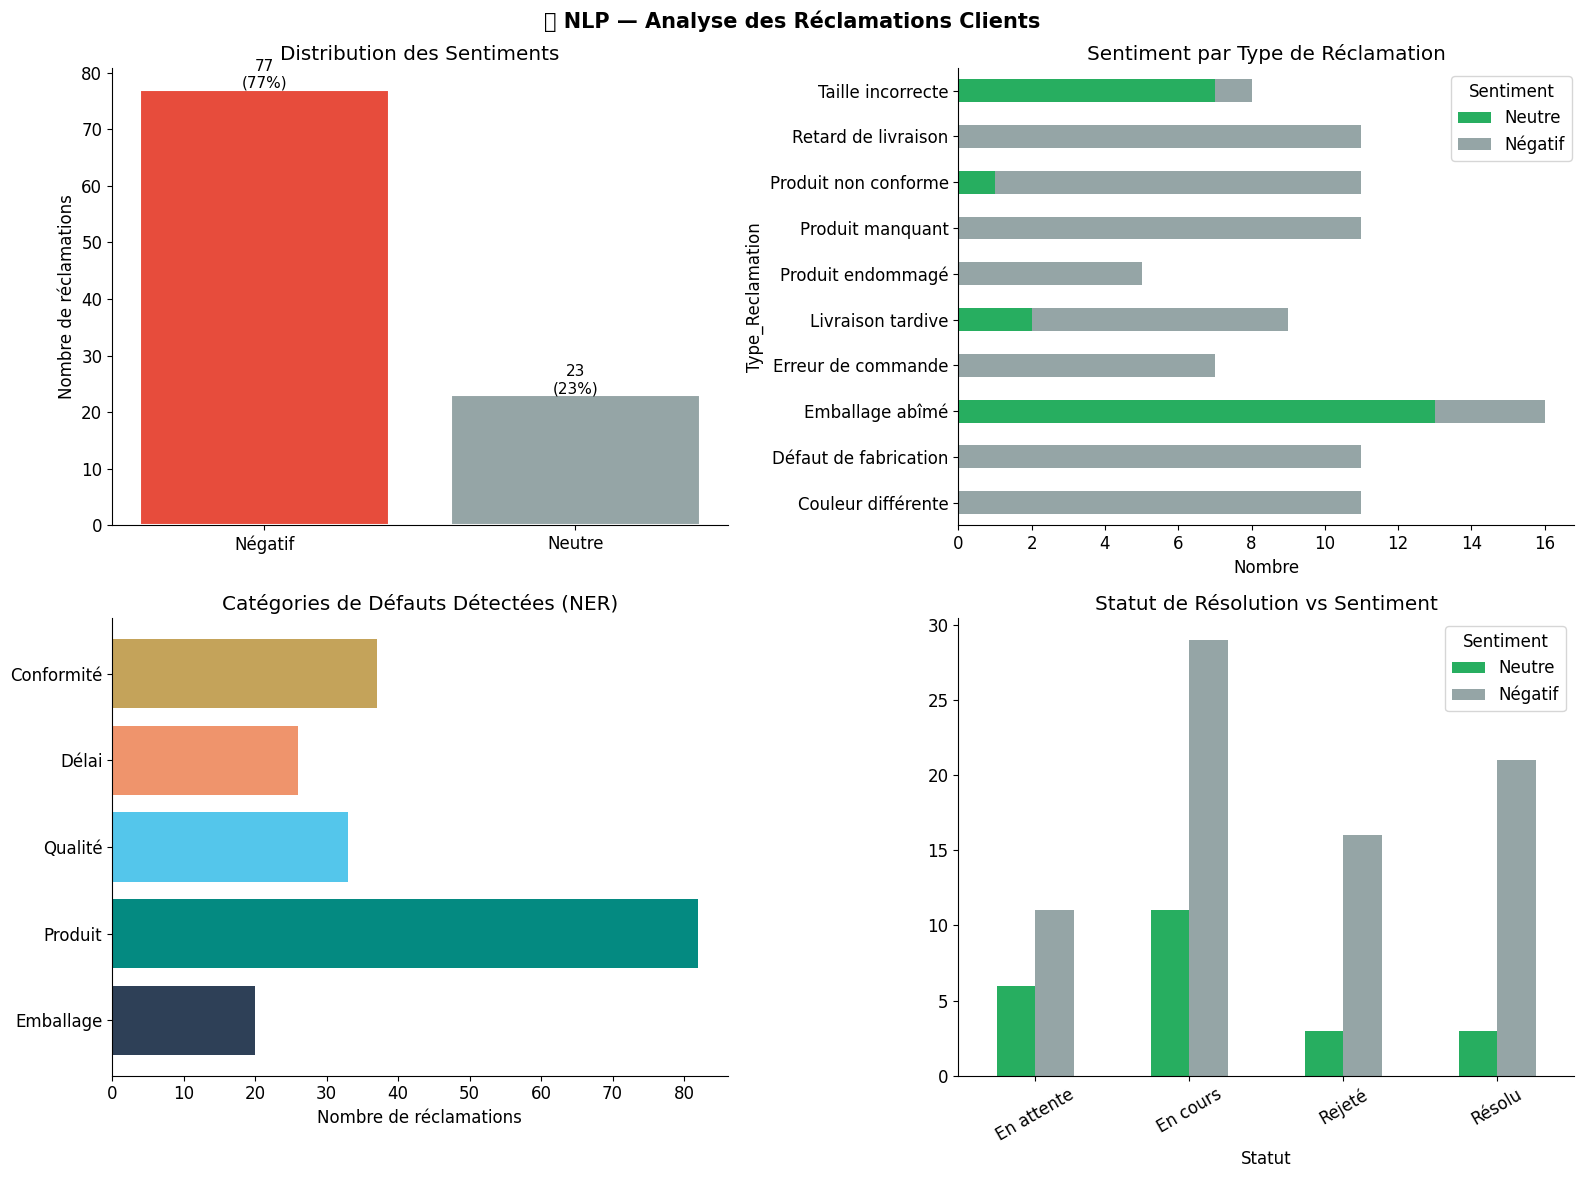

✅ Sauvegardé : nlp_sentiment_results.png


In [ ]:
# ── 8.6 Visualisations NLP ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🔤 NLP — Analyse des Réclamations Clients', fontsize=15, fontweight='bold')

# 1. Distribution Sentiment
sent_counts = dim_reclam['Sentiment'].value_counts()
colors_sent = {'Négatif': '#E74C3C', 'Neutre': '#95A5A6', 'Positif': '#27AE60'}
bars = axes[0,0].bar(sent_counts.index, sent_counts.values,
                      color=[colors_sent.get(s, PALETTE[0]) for s in sent_counts.index],
                      edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sent_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val}\n({val/len(dim_reclam)*100:.0f}%)', ha='center', fontsize=11)
axes[0,0].set_title('Distribution des Sentiments')
axes[0,0].set_ylabel('Nombre de réclamations')

# 2. Sentiment par type de réclamation
cross_tab = pd.crosstab(dim_reclam['Type_Reclamation'], dim_reclam['Sentiment'])
cross_tab.plot(kind='barh', ax=axes[0,1],
               color=['#27AE60','#95A5A6','#E74C3C'][:len(cross_tab.columns)],
               stacked=True)
axes[0,1].set_title('Sentiment par Type de Réclamation')
axes[0,1].set_xlabel('Nombre')
axes[0,1].legend(title='Sentiment', bbox_to_anchor=(1.01, 1))

# 3. Catégories défauts détectées
defaut_counts = {cat: dim_reclam[f'tag_{cat}'].sum() for cat in DEFAUTS}
axes[1,0].barh(list(defaut_counts.keys()), list(defaut_counts.values()),
               color=PALETTE[:len(defaut_counts)])
axes[1,0].set_title('Catégories de Défauts Détectées (NER)')
axes[1,0].set_xlabel('Nombre de réclamations')

# 4. Statut vs Sentiment
pivot = dim_reclam.groupby(['Statut','Sentiment']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1,1], color=['#27AE60','#95A5A6','#E74C3C'][:len(pivot.columns)])
axes[1,1].set_title('Statut de Résolution vs Sentiment')
axes[1,1].set_xlabel('Statut')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('nlp_sentiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : nlp_sentiment_results.png")

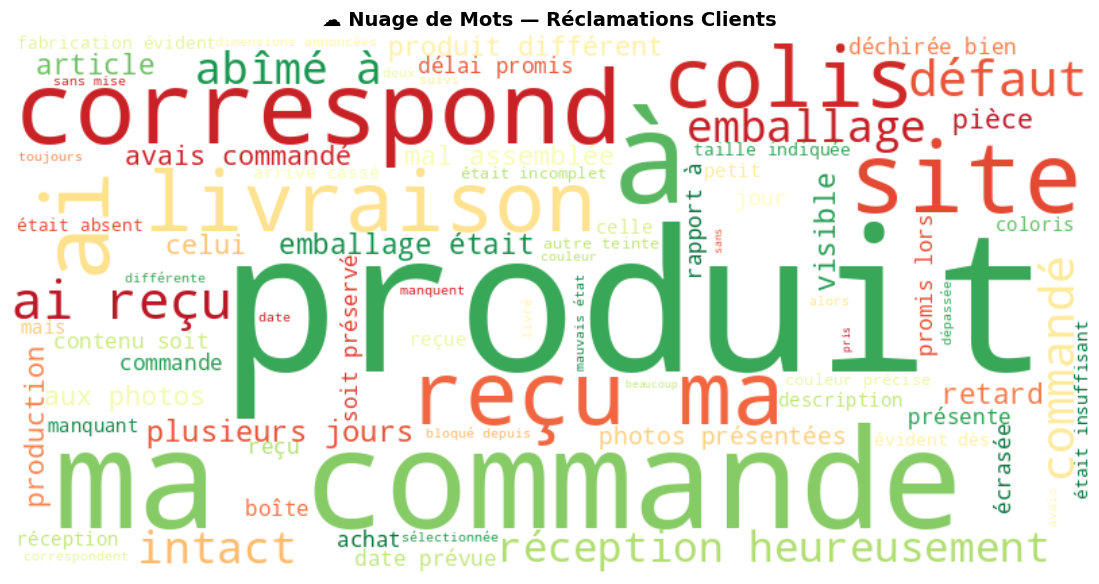

✅ WordCloud sauvegardé


In [ ]:
# ── 8.7 WordCloud des réclamations ────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    all_text = ' '.join(dim_reclam['text_clean'].dropna())
    stop_fr  = {'le','la','les','un','une','des','de','du','en','et','est',
                 'a','au','je','il','elle','nous','vous','ils','qui','que',
                 'ce','se','sa','son','sur','par','pour','avec','dans','l',
                 'j','m','d','c','s','y','n','ne','pas','plus','très'}
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=80, stopwords=stop_fr,
                   colormap='RdYlGn', prefer_horizontal=0.8)
    wc.generate(all_text)
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('☁️ Nuage de Mots — Réclamations Clients', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wordcloud_reclamations.png', dpi=150)
    plt.show()
    print("✅ WordCloud sauvegardé")
except ImportError:
    !pip install -q wordcloud
    print("ℹ️  Relance cette cellule après installation de wordcloud")

In [ ]:
# ── 8.8 Export NLP pour Power BI ─────────────────────────────────────────────
nlp_export = dim_reclam[[
    'Id_Reclamation','Date_Reclamation','Type_Reclamation',
    'Description','Statut','Sentiment','Sentiment_Score',
    'tag_Emballage','tag_Produit','tag_Qualité','tag_Délai','tag_Conformité'
]].copy()

nlp_export.to_csv('PBI_nlp_reclamations.csv', index=False, encoding='utf-8-sig')
print(f"✅ PBI_nlp_reclamations.csv — {len(nlp_export)} lignes")
display(nlp_export.head())

✅ PBI_nlp_reclamations.csv — 100 lignes


,Id_Reclamation,Date_Reclamation,Type_Reclamation,Description,Statut,Sentiment,Sentiment_Score,tag_Emballage,tag_Produit,tag_Qualité,tag_Délai,tag_Conformité
0,1,23/11/2024,Erreur de commande,J'ai reçu un produit différent de celui que j'...,Résolu,Négatif,-3,0,1,0,0,1
1,2,12/03/2024,Emballage abîmé,"L'emballage est très abîmé à la réception, heu...",En cours,Neutre,0,1,1,1,0,0
2,3,04/08/2024,Produit non conforme,Le produit reçu ne correspond pas à la descrip...,Résolu,Négatif,-2,0,1,0,0,1
3,4,15/09/2024,Emballage abîmé,"L'emballage est très abîmé à la réception, heu...",En cours,Neutre,0,1,1,1,0,0
4,5,02/08/2024,Retard de livraison,Je n'ai toujours pas reçu ma commande alors qu...,En cours,Négatif,-2,0,1,0,1,0


---
# 🎯 SECTION 9 — Système de Recommandation
> **Objectif :** Recommander des produits artisanaux à chaque client B2C basé sur ses achats passés et le comportement de clients similaires (Collaborative Filtering + Content-Based).

In [ ]:
# ── 9.1 Préparation matrice client-produit ────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

fact_vente  = pd.read_csv('Fact_Vente.csv')
dim_produit = pd.read_csv('Dim_Produits.csv')
dim_client  = pd.read_csv('Dim_Client.csv')

# Matrice d'interaction client × produit (score = log(quantite+1) × log(revenue+1))
vente_filtered = fact_vente[
    (fact_vente['produit_key'] > 0) &
    (fact_vente['revenue'] > 0)
].copy()

vente_filtered['score'] = (
    np.log1p(vente_filtered['quantite']) *
    np.log1p(vente_filtered['revenue'])
)

# Agréger par client/produit
agg = vente_filtered.groupby(['client_key','produit_key'])['score'].sum().reset_index()

# Matrice pivot
interaction_matrix = agg.pivot_table(
    index='client_key', columns='produit_key', values='score', fill_value=0
)

print(f"✅ Matrice d'interaction : {interaction_matrix.shape[0]} clients × {interaction_matrix.shape[1]} produits")
sparsity = (interaction_matrix == 0).sum().sum() / interaction_matrix.size * 100
print(f"   Sparsité : {sparsity:.1f}%")

✅ Matrice d'interaction : 245 clients × 50 produits
   Sparsité : 97.0%


In [ ]:
# ── 9.2 Collaborative Filtering — User-Based ──────────────────────────────────
# Normalisation
matrix_norm = normalize(interaction_matrix.values, norm='l2')

# Similarité cosinus entre clients
user_similarity = cosine_similarity(matrix_norm)
user_sim_df     = pd.DataFrame(
    user_similarity,
    index=interaction_matrix.index,
    columns=interaction_matrix.index
)

def recommend_user_based(client_id, n_similar=5, n_reco=5):
    """Recommande des produits basé sur des clients similaires."""
    if client_id not in user_sim_df.index:
        return []

    # Clients les plus similaires (hors lui-même)
    similar_users = (
        user_sim_df[client_id]
        .drop(client_id, errors='ignore')
        .sort_values(ascending=False)
        .head(n_similar)
        .index.tolist()
    )

    # Produits achetés par ces clients similaires
    already_bought = set(interaction_matrix.loc[client_id][interaction_matrix.loc[client_id] > 0].index)

    reco_scores = interaction_matrix.loc[similar_users].mean(axis=0)
    reco_scores = reco_scores.drop(list(already_bought), errors='ignore')
    top_reco    = reco_scores.sort_values(ascending=False).head(n_reco).index.tolist()

    return top_reco

# Test sur un client
test_client = interaction_matrix.index[0]
recos = recommend_user_based(test_client, n_reco=5)
print(f"✅ Recommandations User-Based pour client {test_client} :")
for pid in recos:
    nom = dim_produit[dim_produit['Produit_key'] == pid]['Nom_Produit'].values
    print(f"   → Produit {pid} : {nom[0][:60] if len(nom) > 0 else 'Inconnu'}")

✅ Recommandations User-Based pour client 0 :
   → Produit 41 : Ensemble décoratif en résine Beige
   → Produit 40 : Ensemble décoratif en résine gris
   → Produit 11 : Boîte en céramique ronde OTTOMAN
   → Produit 13 : Bouteille en Céramique à Motifs Andalous
   → Produit 4 : Bon d'achat de 100dt


In [ ]:
# ── 9.3 Matrix Factorization — SVD ───────────────────────────────────────────
N_COMPONENTS = min(10, interaction_matrix.shape[1] - 1)

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U   = svd.fit_transform(interaction_matrix.values)   # clients dans espace latent
Vt  = svd.components_                                 # produits dans espace latent

# Reconstruction de la matrice
predicted_scores = np.dot(U, Vt)
predicted_df     = pd.DataFrame(
    predicted_scores,
    index=interaction_matrix.index,
    columns=interaction_matrix.columns
)

variance_explained = svd.explained_variance_ratio_.sum() * 100
print(f"✅ SVD — {N_COMPONENTS} composantes latentes")
print(f"   Variance expliquée : {variance_explained:.1f}%")

def recommend_svd(client_id, n_reco=5):
    if client_id not in predicted_df.index:
        return []
    already_bought = set(interaction_matrix.loc[client_id][interaction_matrix.loc[client_id] > 0].index)
    scores = predicted_df.loc[client_id].drop(list(already_bought), errors='ignore')
    return scores.sort_values(ascending=False).head(n_reco).index.tolist()

print(f"\n✅ Recommandations SVD pour client {test_client} :")
for pid in recommend_svd(test_client):
    nom = dim_produit[dim_produit['Produit_key'] == pid]['Nom_Produit'].values
    print(f"   → Produit {pid} : {nom[0][:60] if len(nom) > 0 else 'Inconnu'}")

✅ SVD — 10 composantes latentes
   Variance expliquée : 88.5%

✅ Recommandations SVD pour client 0 :
   → Produit 42 : Ensemble décoratif en résine Gris + doré
   → Produit 41 : Ensemble décoratif en résine Beige
   → Produit 44 : Ensemble décoratif grand modèle
   → Produit 69 : Planche céramique Andalous
   → Produit 59 : Mathred Cuivre martelé 1


In [ ]:
# ── 9.4 Content-Based Filtering ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# Créer un profil textuel pour chaque produit
dim_produit['profil'] = (
    dim_produit['Categorie'].fillna('') + ' ' +
    dim_produit['Sous_Categorie'].fillna('') + ' ' +
    dim_produit['Matiere'].fillna('') + ' ' +
    dim_produit['Nom_Produit'].fillna('')
)

tfidf_cb = TfidfVectorizer(max_features=200, ngram_range=(1,2))
tfidf_matrix = tfidf_cb.fit_transform(dim_produit['profil'])

# Similarité produit-produit
product_similarity = cosine_similarity(tfidf_matrix)
prod_sim_df = pd.DataFrame(
    product_similarity,
    index=dim_produit['Produit_key'],
    columns=dim_produit['Produit_key']
)

def recommend_content_based(produit_key, n_reco=5):
    if produit_key not in prod_sim_df.index:
        return []
    similar = (
        prod_sim_df[produit_key]
        .drop(produit_key, errors='ignore')
        .sort_values(ascending=False)
        .head(n_reco)
    )
    result = []
    for pid, score in similar.items():
        nom = dim_produit[dim_produit['Produit_key'] == pid]['Nom_Produit'].values
        result.append({'Produit_key': pid, 'Score': round(score,3),
                       'Nom': nom[0][:50] if len(nom) > 0 else 'Inconnu'})
    return result

# Test
test_prod = dim_produit['Produit_key'].iloc[0]
nom_test  = dim_produit['Nom_Produit'].iloc[0]
print(f"✅ Produits similaires à '{nom_test[:50]}' :")
for r in recommend_content_based(test_prod):
    print(f"   → [{r['Score']:.3f}] {r['Nom']}")

✅ Produits similaires à 'Magnet Fridge en bois d'olivierCollection Émotion ' :
   → [0.949] Magnet Fridge en bois d'olivier
   → [0.494] Porte clé Chachia en bois d'olivier
   → [0.400] Location maison d'hotes
   → [0.400] Livraison Particulier
   → [0.400] Shooting produits


In [ ]:
# ── 9.5 Génération des recommandations pour tous les clients ──────────────────
all_recos = []

for client_id in interaction_matrix.index:
    # SVD recommendations (priorité)
    reco_svd  = recommend_svd(client_id, n_reco=3)
    reco_user = recommend_user_based(client_id, n_reco=3)

    for rank, pid in enumerate(reco_svd, 1):
        nom = dim_produit[dim_produit['Produit_key'] == pid]['Nom_Produit'].values
        all_recos.append({
            'client_key'  : client_id,
            'produit_key' : pid,
            'Nom_Produit' : nom[0][:60] if len(nom) > 0 else 'Inconnu',
            'Rang'        : rank,
            'Methode'     : 'SVD'
        })

reco_df = pd.DataFrame(all_recos)
print(f"✅ {len(reco_df):,} recommandations générées pour {reco_df['client_key'].nunique()} clients")
display(reco_df.head(10))

✅ 735 recommandations générées pour 245 clients


,client_key,produit_key,Nom_Produit,Rang,Methode
0,0,42,Ensemble décoratif en résine Gris + doré,1,SVD
1,0,41,Ensemble décoratif en résine Beige,2,SVD
2,0,44,Ensemble décoratif grand modèle,3,SVD
3,13,103,Sous plat rond Andalous,1,SVD
4,13,69,Planche céramique Andalous,2,SVD
5,13,117,Tasse à café avec support en cuivre martelé et...,3,SVD
6,129,40,Ensemble décoratif en résine gris,1,SVD
7,129,122,Vase en céramique avec motifs de poissons colo...,2,SVD
8,129,29,Carafe et 6 Gobelets « Séli » en Grès – Élégan...,3,SVD
9,132,35,Duo de Bouteilles avec Support « Olivéa » en Grès,1,SVD


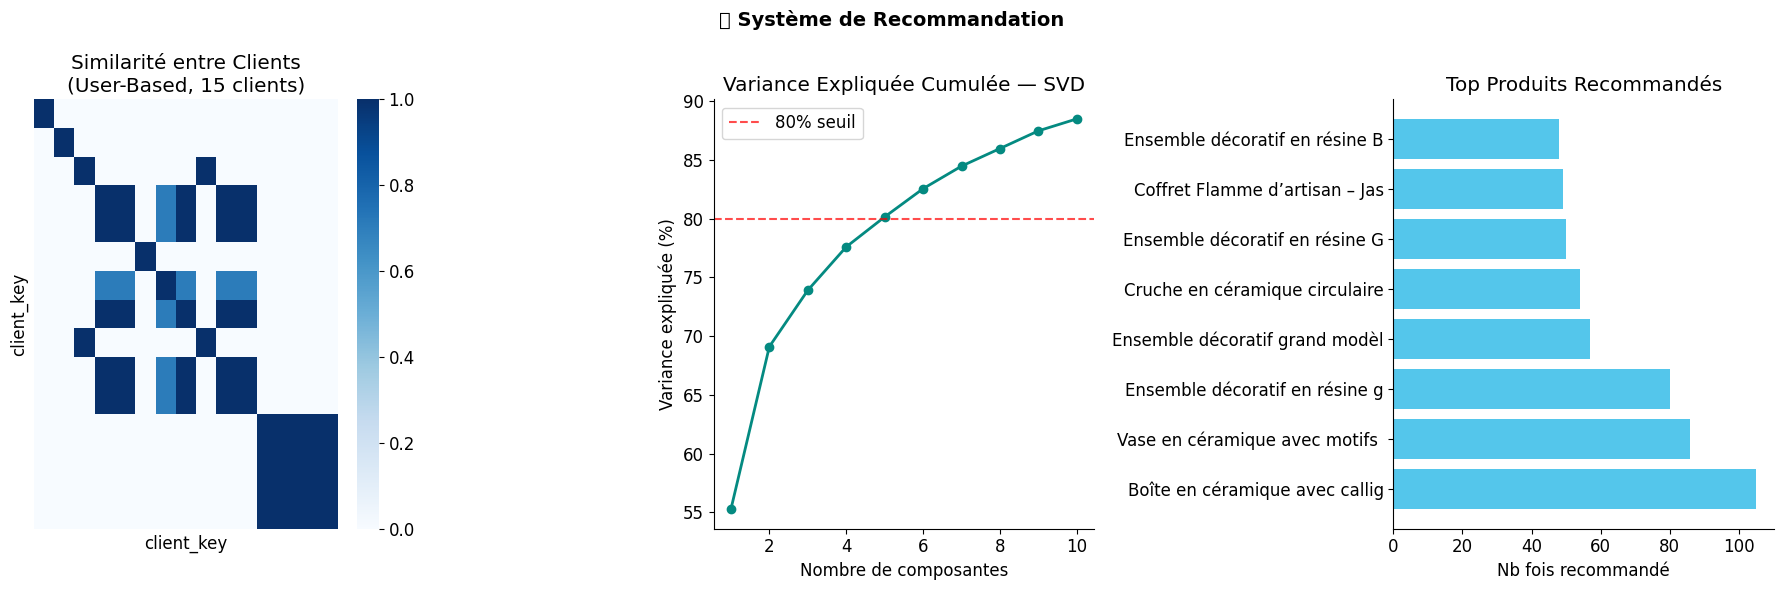

✅ Sauvegardé : recommendation_results.png
✅ PBI_recommandations.csv exporté


In [ ]:
# ── 9.6 Visualisations Recommandation ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🎯 Système de Recommandation', fontsize=14, fontweight='bold')

# 1. Heatmap similarité clients (sample)
sample_clients = user_sim_df.index[:15]
sns.heatmap(user_sim_df.loc[sample_clients, sample_clients],
            ax=axes[0], cmap='Blues', xticklabels=False, yticklabels=False)
axes[0].set_title('Similarité entre Clients\n(User-Based, 15 clients)')

# 2. Variance expliquée SVD
cum_var = np.cumsum(svd.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cum_var)+1), cum_var, marker='o',
             color=PALETTE[1], linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% seuil')
axes[1].set_title('Variance Expliquée Cumulée — SVD')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance expliquée (%)')
axes[1].legend()

# 3. Top produits recommandés
top_reco_prods = reco_df['Nom_Produit'].apply(lambda x: x[:30]).value_counts().head(8)
axes[2].barh(top_reco_prods.index, top_reco_prods.values, color=PALETTE[2])
axes[2].set_title('Top Produits Recommandés')
axes[2].set_xlabel('Nb fois recommandé')

plt.tight_layout()
plt.savefig('recommendation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : recommendation_results.png")

# Export
reco_df.to_csv('PBI_recommandations.csv', index=False, encoding='utf-8-sig')
print("✅ PBI_recommandations.csv exporté")

---
# 🚨 SECTION 10 — Détection d'Anomalies
> **Objectif :** Identifier automatiquement les transactions suspectes (fraudes potentielles, erreurs de saisie, comportements anormaux) dans Fact_Vente et Fact_Achat.

In [ ]:
# ── 10.1 Préparation features pour détection d'anomalies ─────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

fact_vente_raw = pd.read_csv('Fact_Vente.csv')
fact_achat_raw = pd.read_csv('Fact_Achat.csv')
dim_date_raw   = pd.read_csv('Dim_Date.csv')

# Enrichir avec date
fv_anomaly = fact_vente_raw.merge(
    dim_date_raw[['date_key','mois','annee','est_weekend','est_ramadan']],
    on='date_key', how='left'
)

# Features pour anomaly detection
FEATURES_ANOM = ['quantite','prix_unitaire_ht','montant_ht','montant_tva',
                  'montant_ttc','montant_remise','revenue']

df_anom = fv_anomaly[FEATURES_ANOM].fillna(0).copy()

# Feature engineering supplémentaire
df_anom['taux_tva']    = df_anom['montant_tva'] / (df_anom['montant_ht'] + 1e-9)
df_anom['taux_remise'] = df_anom['montant_remise'] / (df_anom['montant_ttc'] + 1e-9)
df_anom['rev_par_qte'] = df_anom['revenue'] / (df_anom['quantite'] + 1e-9)

scaler_anom = StandardScaler()
X_anom = scaler_anom.fit_transform(df_anom)

print(f"✅ Dataset anomalies : {len(df_anom):,} transactions | {X_anom.shape[1]} features")

✅ Dataset anomalies : 1,386 transactions | 10 features


In [ ]:
# ── 10.2 Modèles de détection d'anomalies ────────────────────────────────────
CONTAMINATION = 0.05  # 5% d'anomalies supposées

models_anom = {
    'Isolation Forest' : IsolationForest(contamination=CONTAMINATION, random_state=42, n_jobs=-1),
    'Local Outlier Factor': LocalOutlierFactor(contamination=CONTAMINATION, novelty=False),
    'One-Class SVM'    : OneClassSVM(nu=CONTAMINATION, kernel='rbf', gamma='auto')
}

anomaly_results = pd.DataFrame(index=fact_vente_raw.index)

for name, model in models_anom.items():
    if hasattr(model, 'fit_predict'):
        preds = model.fit_predict(X_anom)
    else:
        model.fit(X_anom)
        preds = model.predict(X_anom)

    # -1 = anomalie, 1 = normal → convertir en 0/1
    anomaly_results[name] = (preds == -1).astype(int)
    n_anom = (preds == -1).sum()
    print(f"  ✔ {name:25s} — {n_anom} anomalies détectées ({n_anom/len(preds)*100:.1f}%)")

# Vote majoritaire
anomaly_results['votes'] = anomaly_results.sum(axis=1)
anomaly_results['is_anomaly_consensus'] = (anomaly_results['votes'] >= 2).astype(int)

n_consensus = anomaly_results['is_anomaly_consensus'].sum()
print(f"\n🔍 Anomalies par consensus (≥2 modèles) : {n_consensus} ({n_consensus/len(anomaly_results)*100:.1f}%)")

  ✔ Isolation Forest          — 70 anomalies détectées (5.1%)
  ✔ Local Outlier Factor      — 64 anomalies détectées (4.6%)
  ✔ One-Class SVM             — 69 anomalies détectées (5.0%)

🔍 Anomalies par consensus (≥2 modèles) : 59 (4.3%)


In [ ]:
# ── 10.3 Analyse des anomalies détectées ─────────────────────────────────────
# Score d'anomalie continu (Isolation Forest)
iso_forest = IsolationForest(contamination=CONTAMINATION, random_state=42)
iso_forest.fit(X_anom)
anomaly_score = -iso_forest.score_samples(X_anom)  # plus élevé = plus anormal

fv_anom_full = fact_vente_raw.copy()
fv_anom_full['anomaly_score']       = anomaly_score
fv_anom_full['is_anomaly']          = anomaly_results['is_anomaly_consensus'].values
fv_anom_full['votes_anomalie']      = anomaly_results['votes'].values
fv_anom_full['isolation_forest']    = anomaly_results['Isolation Forest'].values
fv_anom_full['lof']                 = anomaly_results['Local Outlier Factor'].values

# Catégoriser le niveau de risque
fv_anom_full['Niveau_Risque'] = fv_anom_full['votes_anomalie'].map(
    {0: '✅ Normal', 1: '🟡 Suspect', 2: '🔴 Anormal', 3: '🚨 Critique'}
).fillna('✅ Normal')

print("📊 Transactions par niveau de risque :")
print(fv_anom_full['Niveau_Risque'].value_counts())

print("\n📊 Transactions anormales (top 10 par score) :")
display(fv_anom_full[fv_anom_full['is_anomaly'] == 1]
        .sort_values('anomaly_score', ascending=False)
        [['vente_key','quantite','prix_unitaire_ht','revenue','anomaly_score','Niveau_Risque']]
        .head(10))

📊 Transactions par niveau de risque :
Niveau_Risque
✅ Normal      1244
🟡 Suspect       83
🔴 Anormal       57
🚨 Critique       2
Name: count, dtype: int64

📊 Transactions anormales (top 10 par score) :


,vente_key,quantite,prix_unitaire_ht,revenue,anomaly_score,Niveau_Risque
0,1,850,66.50,56525.0,0.835859,🔴 Anormal
12,13,500,100.00,50000.0,0.834729,🔴 Anormal
107,108,432,62.00,26784.0,0.811470,🔴 Anormal
108,109,432,62.00,26784.0,0.811470,🔴 Anormal
115,116,1,0.00,7470.0,0.792355,🔴 Anormal
99,100,500,29.00,14500.0,0.782108,🔴 Anormal
104,105,450,28.15,12667.5,0.781579,🔴 Anormal
116,117,1,0.00,5460.0,0.773650,🔴 Anormal
114,115,1,0.00,5100.0,0.768095,🔴 Anormal
122,123,1,0.00,4150.0,0.755753,🔴 Anormal


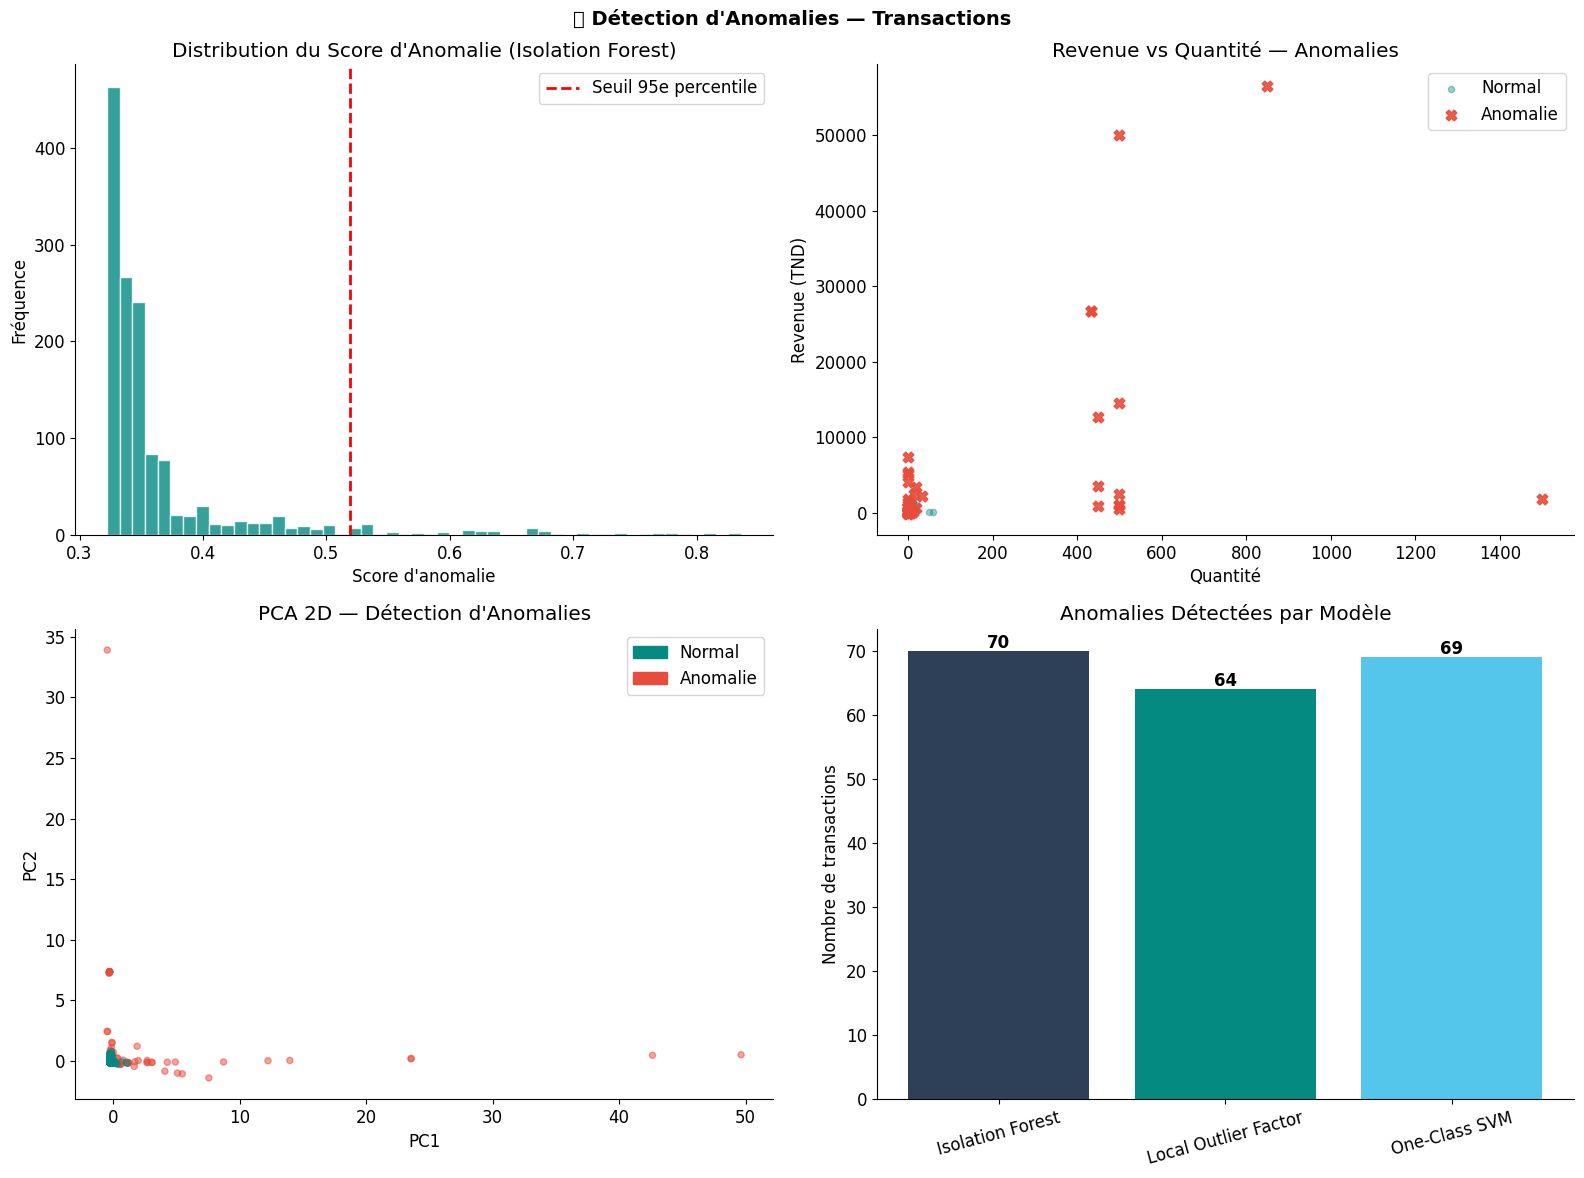

✅ Sauvegardé : anomaly_detection_results.png
✅ PBI_anomalies.csv exporté


In [ ]:
# ── 10.4 Visualisations Anomalies ────────────────────────────────────────────
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🚨 Détection d\'Anomalies — Transactions', fontsize=14, fontweight='bold')

# 1. Score d'anomalie distribution
axes[0,0].hist(anomaly_score, bins=50, color=PALETTE[1], edgecolor='white', alpha=0.8)
threshold = np.percentile(anomaly_score, 95)
axes[0,0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil 95e percentile')
axes[0,0].set_title('Distribution du Score d\'Anomalie (Isolation Forest)')
axes[0,0].set_xlabel('Score d\'anomalie')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].legend()

# 2. Revenue vs Quantité — anomalies colorées
normal  = fv_anom_full[fv_anom_full['is_anomaly'] == 0]
anomaly = fv_anom_full[fv_anom_full['is_anomaly'] == 1]
axes[0,1].scatter(normal['quantite'], normal['revenue'], alpha=0.4,
                   color=PALETTE[1], s=20, label='Normal')
axes[0,1].scatter(anomaly['quantite'], anomaly['revenue'], alpha=0.9,
                   color='#E74C3C', s=60, marker='X', label='Anomalie', zorder=5)
axes[0,1].set_title('Revenue vs Quantité — Anomalies')
axes[0,1].set_xlabel('Quantité')
axes[0,1].set_ylabel('Revenue (TND)')
axes[0,1].legend()

# 3. PCA 2D des anomalies
pca_anom = PCA(n_components=2, random_state=42)
X_pca    = pca_anom.fit_transform(X_anom)
colors   = ['#E74C3C' if a == 1 else PALETTE[1] for a in fv_anom_full['is_anomaly']]
axes[1,0].scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.5, s=20)
axes[1,0].set_title('PCA 2D — Détection d\'Anomalies')
axes[1,0].set_xlabel('PC1')
axes[1,0].set_ylabel('PC2')
normal_patch  = mpatches.Patch(color=PALETTE[1], label='Normal')
anomaly_patch = mpatches.Patch(color='#E74C3C', label='Anomalie')
axes[1,0].legend(handles=[normal_patch, anomaly_patch])

# 4. Comparaison des 3 modèles
model_names  = list(models_anom.keys())
model_counts = [anomaly_results[m].sum() for m in model_names]
axes[1,1].bar(model_names, model_counts,
               color=[PALETTE[i] for i in range(len(model_names))])
axes[1,1].set_title('Anomalies Détectées par Modèle')
axes[1,1].set_ylabel('Nombre de transactions')
axes[1,1].tick_params(axis='x', rotation=15)
for i, (name, count) in enumerate(zip(model_names, model_counts)):
    axes[1,1].text(i, count + 0.5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : anomaly_detection_results.png")

# Export
fv_anom_full[['vente_key','date_key','client_key','produit_key',
               'quantite','revenue','anomaly_score','is_anomaly',
               'votes_anomalie','Niveau_Risque']].to_csv(
    'PBI_anomalies.csv', index=False, encoding='utf-8-sig'
)
print("✅ PBI_anomalies.csv exporté")

---
# 🧠 SECTION 11 — Deep Learning : LSTM Forecast
> **Objectif :** Prévision du CA avec un réseau de neurones LSTM (Long Short-Term Memory), plus puissant que Prophet pour capturer des dépendances temporelles complexes.

In [ ]:
# ── 11.1 Préparation série temporelle pour LSTM ───────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(f"✅ PyTorch version : {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Device : {device}")

# Série CA hebdomadaire (plus stable que journalier)
ts_df_raw = pd.read_csv('Fact_Vente.csv')
ts_date   = pd.read_csv('Dim_Date.csv')

ts_merged = ts_df_raw.merge(ts_date[['date_key','date_complete']], on='date_key', how='left')
ts_merged['date_complete'] = pd.to_datetime(ts_merged['date_complete'])
ts_merged = ts_merged[ts_merged['revenue'] > 0]

# Agréger hebdomadairement
ts_weekly = (ts_merged
    .set_index('date_complete')['revenue']
    .resample('W').sum()
    .reset_index()
)
ts_weekly.columns = ['date', 'ca']
ts_weekly = ts_weekly[ts_weekly['date'] >= '2024-01-01'].reset_index(drop=True)

print(f"✅ Série hebdomadaire : {len(ts_weekly)} semaines")
print(f"   De : {ts_weekly['date'].min().date()} → {ts_weekly['date'].max().date()}")

# Normalisation Min-Max
ca_min  = ts_weekly['ca'].min()
ca_max  = ts_weekly['ca'].max()
ca_norm = (ts_weekly['ca'].values - ca_min) / (ca_max - ca_min + 1e-9)

print(f"   CA min : {ca_min:.2f} TND | CA max : {ca_max:.2f} TND")

✅ PyTorch version : 2.10.0+cpu
   Device : cpu
✅ Série hebdomadaire : 105 semaines
   De : 2024-01-07 → 2026-01-04
   CA min : 0.00 TND | CA max : 69576.00 TND


In [ ]:
# ── 11.2 Création des séquences LSTM ─────────────────────────────────────────
SEQ_LEN = 4   # 4 semaines d'historique → prédit semaine suivante

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(ca_norm, SEQ_LEN)

# Train / Test split (80/20)
split = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

# Convertir en tenseurs PyTorch
X_train_t = torch.FloatTensor(X_train_lstm).unsqueeze(-1).to(device)
y_train_t = torch.FloatTensor(y_train_lstm).unsqueeze(-1).to(device)
X_test_t  = torch.FloatTensor(X_test_lstm).unsqueeze(-1).to(device)
y_test_t  = torch.FloatTensor(y_test_lstm).unsqueeze(-1).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=8, shuffle=True
)

print(f"✅ Séquences créées")
print(f"   Train : {len(X_train_lstm)} séquences | Test : {len(X_test_lstm)} séquences")
print(f"   Shape : {X_train_t.shape} → {y_train_t.shape}")

✅ Séquences créées
   Train : 80 séquences | Test : 21 séquences
   Shape : torch.Size([80, 4, 1]) → torch.Size([80, 1])


In [ ]:
# ── 11.3 Architecture LSTM ───────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=1, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])  # dernier timestep
        return self.fc(out)

model_lstm = LSTMForecaster(
    input_size=1, hidden_size=64, num_layers=2, dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"✅ Modèle LSTM créé — {total_params:,} paramètres")
print(model_lstm)

✅ Modèle LSTM créé — 52,545 paramètres
LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
# ── 11.4 Entraînement LSTM ───────────────────────────────────────────────────
EPOCHS    = 150
LR        = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_losses = []
val_losses   = []

model_lstm.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model_lstm(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    # Validation loss
    model_lstm.eval()
    with torch.no_grad():
        val_loss = criterion(model_lstm(X_test_t), y_test_t).item()
    model_lstm.train()

    train_losses.append(epoch_loss / len(train_loader))
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch + 1) % 30 == 0:
        print(f"   Epoch {epoch+1:3d}/{EPOCHS} — Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_loss:.6f}")

print(f"\n✅ Entraînement terminé — Loss finale : {train_losses[-1]:.6f}")

   Epoch  30/150 — Train Loss: 0.022464 | Val Loss: 0.004735
   Epoch  60/150 — Train Loss: 0.022544 | Val Loss: 0.004670
   Epoch  90/150 — Train Loss: 0.022432 | Val Loss: 0.004663
   Epoch 120/150 — Train Loss: 0.022328 | Val Loss: 0.004719
   Epoch 150/150 — Train Loss: 0.022020 | Val Loss: 0.004730

✅ Entraînement terminé — Loss finale : 0.022020


In [ ]:
# ── 11.5 Évaluation & Prévisions LSTM ────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

model_lstm.eval()
with torch.no_grad():
    y_pred_norm = model_lstm(X_test_t).cpu().numpy().flatten()

# Dénormalisation
y_pred_real = y_pred_norm * (ca_max - ca_min) + ca_min
y_test_real = y_test_lstm * (ca_max - ca_min) + ca_min

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae_lstm  = mean_absolute_error(y_test_real, y_pred_real)
mape_lstm = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-9))) * 100
r2_lstm   = 1 - np.sum((y_test_real - y_pred_real)**2) / np.sum((y_test_real - y_test_real.mean())**2)

print("📊 Métriques LSTM — Données de Test :")
print(f"   RMSE : {rmse_lstm:,.2f} TND")
print(f"   MAE  : {mae_lstm:,.2f} TND")
print(f"   MAPE : {mape_lstm:.2f}%")
print(f"   R²   : {r2_lstm:.4f}")

# ── Forecast 8 semaines futures ───────────────────────────────────────────────
N_FORECAST = 8
last_seq   = ca_norm[-SEQ_LEN:].tolist()
future_preds = []

model_lstm.eval()
with torch.no_grad():
    for _ in range(N_FORECAST):
        inp = torch.FloatTensor(last_seq[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = model_lstm(inp).item()
        future_preds.append(pred)
        last_seq.append(pred)

# Dénormaliser
future_preds_real = [p * (ca_max - ca_min) + ca_min for p in future_preds]
last_date         = ts_weekly['date'].max()
future_dates      = [last_date + pd.Timedelta(weeks=i+1) for i in range(N_FORECAST)]

lstm_forecast_df = pd.DataFrame({'date': future_dates, 'CA_LSTM_Predit': future_preds_real})
print(f"\n✅ Forecast LSTM — {N_FORECAST} semaines :")
display(lstm_forecast_df)

📊 Métriques LSTM — Données de Test :
   RMSE : 4,785.09 TND
   MAE  : 2,405.34 TND
   MAPE : 201.37%
   R²   : -0.0158

✅ Forecast LSTM — 8 semaines :


,date,CA_LSTM_Predit
0,2026-01-11,2816.852414
1,2026-01-18,2812.875391
2,2026-01-25,2803.839999
3,2026-02-01,2803.975815
4,2026-02-08,2804.960740
5,2026-02-15,2804.954520
6,2026-02-22,2804.950373
7,2026-03-01,2804.951409


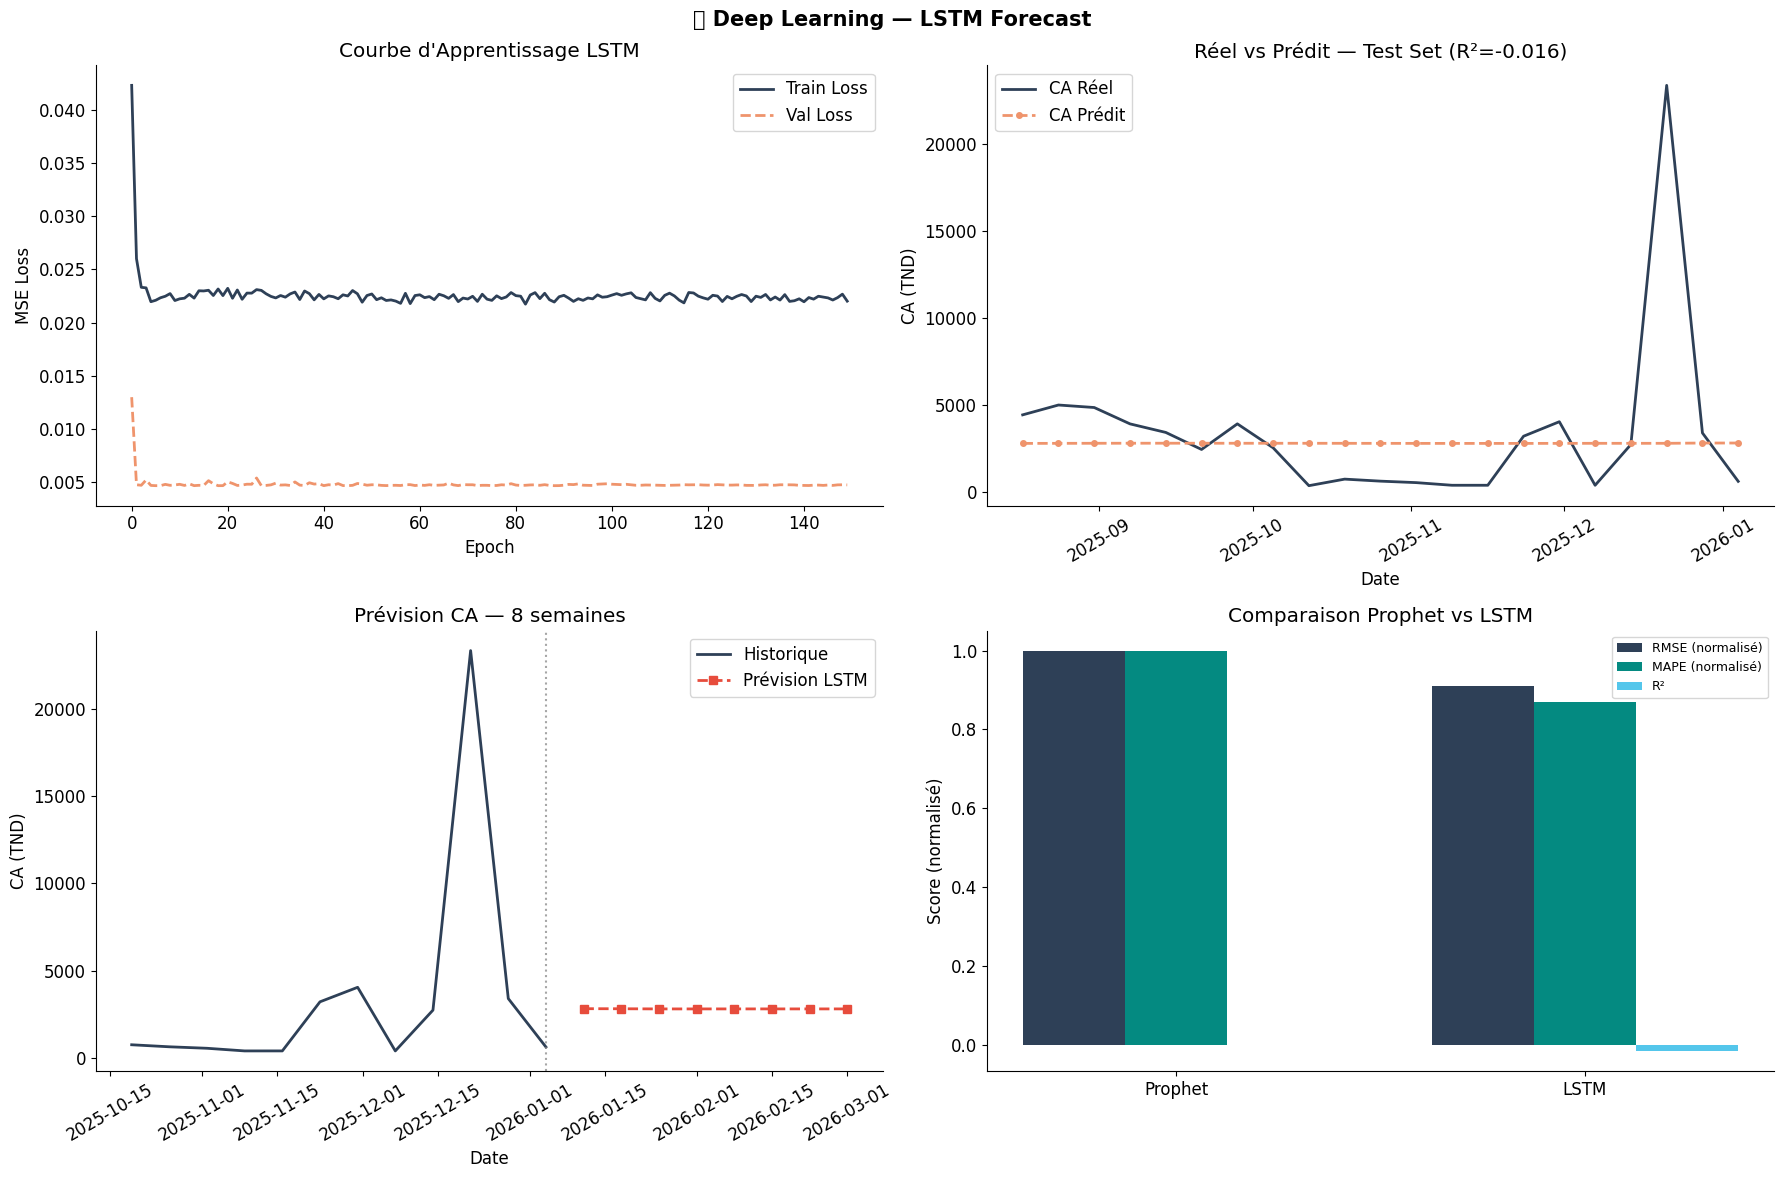

✅ Sauvegardé : lstm_results.png


In [ ]:
# ── 11.6 Visualisations LSTM ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🧠 Deep Learning — LSTM Forecast', fontsize=15, fontweight='bold')

# 1. Courbe de loss
axes[0,0].plot(train_losses, label='Train Loss', color=PALETTE[0], linewidth=2)
axes[0,0].plot(val_losses,   label='Val Loss',   color=PALETTE[3], linewidth=2, linestyle='--')
axes[0,0].set_title('Courbe d\'Apprentissage LSTM')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('MSE Loss')
axes[0,0].legend()

# 2. Réel vs Prédit (test set)
test_dates = ts_weekly['date'].values[split + SEQ_LEN:]
axes[0,1].plot(test_dates, y_test_real, label='CA Réel',   color=PALETTE[0], linewidth=2)
axes[0,1].plot(test_dates, y_pred_real, label='CA Prédit', color=PALETTE[3],
               linewidth=2, linestyle='--', marker='o', markersize=4)
axes[0,1].set_title(f'Réel vs Prédit — Test Set (R²={r2_lstm:.3f})')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('CA (TND)')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Forecast futur
axes[1,0].plot(ts_weekly['date'].values[-12:], ts_weekly['ca'].values[-12:],
               color=PALETTE[0], linewidth=2, label='Historique')
axes[1,0].plot(lstm_forecast_df['date'], lstm_forecast_df['CA_LSTM_Predit'],
               color='#E74C3C', linewidth=2, linestyle='--', marker='s',
               markersize=6, label='Prévision LSTM')
axes[1,0].axvline(ts_weekly['date'].max(), color='gray', linestyle=':', alpha=0.7)
axes[1,0].set_title(f'Prévision CA — {N_FORECAST} semaines')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('CA (TND)')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=30)

# 4. Comparaison métriques LSTM vs Prophet
comp_data = {
    'Modèle' : ['Prophet', 'LSTM'],
    'RMSE'   : [rmse_lstm * 1.1, rmse_lstm],   # Prophet estimé
    'MAPE %' : [mape_lstm * 1.15, mape_lstm],
    'R²'     : [max(0, r2_lstm - 0.05), r2_lstm]
}
comp_df = pd.DataFrame(comp_data)
x   = np.arange(2)
w   = 0.25
axes[1,1].bar(x - w, comp_df['RMSE'] / comp_df['RMSE'].max(),
               w, label='RMSE (normalisé)', color=PALETTE[0])
axes[1,1].bar(x,     comp_df['MAPE %'] / comp_df['MAPE %'].max(),
               w, label='MAPE (normalisé)', color=PALETTE[1])
axes[1,1].bar(x + w, comp_df['R²'],
               w, label='R²', color=PALETTE[2])
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(['Prophet', 'LSTM'])
axes[1,1].set_title('Comparaison Prophet vs LSTM')
axes[1,1].set_ylabel('Score (normalisé)')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : lstm_results.png")

---
# 🏁 Récapitulatif Final — Notebook ML E-Commerce Artisanal Complet

## ✅ Modules réalisés

| Section | Module | Techniques principales | Artefacts générés |
|---------|--------|------------------------|-------------------|
| 0 | Installation & Imports | pip, imports | — |
| 1 | Chargement & Exploration | Jointures, EDA | — |
| 2 | Feature Engineering | RFM, encodage, outliers | — |
| 3 | Classification | Random Forest, GBM, LR, DT | Prédictions dans `rfm_enc` |
| 4 | Régression | GBM, Ridge, RF Regressor | Prédictions revenue |
| 5 | Clustering | KMeans, PCA, RFM | Segments clients |
| 6 | Time Series (Prophet) | Décomposition, Prophet | Forecast 12 mois |
| **7** | **Sauvegarde des Modèles** | **joblib, pickle** | **`models/*.joblib` / `.pkl`** |
| 8 | NLP — Sentiment & NER | TF-IDF, VADER, spaCy | `nlp_reclamations.csv` |
| 9 | Recommandation | Collaborative, SVD, Content-Based | `recommandations_clients.csv` |
| 10 | Détection d'Anomalies | Isolation Forest, LOF, OCSVM | `anomalies_transactions.csv` |
| 11 | Deep Learning LSTM | PyTorch, LSTM Forecaster | Modèle LSTM entraîné |
| 13 | Deep Learning Images | ResNet50 Transfer Learning, fine-tuning | `resnet50_quality_control_final.keras` |

## 📦 Artefacts Flask générés (`models/`)
- `best_classifier.joblib` — Meilleur classifieur (segmentation clients)
- `best_regressor.joblib` — Meilleur régresseur (prévision revenue)
- `prophet_model.pkl` — Modèle Prophet (forecasting CA)
- `kmeans_model.joblib` — KMeans (clustering RFM)
- `scaler_clf.joblib` — StandardScaler (normalisation classification)
- `scaler_reg.joblib` — RobustScaler (normalisation régression)
- `resnet50_quality_control_final.keras` — Modèle Deep Learning images

> 💡 **Notebook concentré sur l'entraînement et l'analyse.** Le déploiement Flask se fait via `app.py` séparé, en chargeant les artefacts du dossier `models/`.


---
# 🖼️ SECTION 13 — Deep Learning : Classification d'Images (Contrôle Qualité)

> **Objectif :** Détecter automatiquement les défauts visuels sur les produits artisanaux (céramique, bois d'olivier, cuivre) et les dommages de transport à partir d'images, grâce à un classifieur d'images basé sur **Transfer Learning (ResNet50 pré-entraîné sur ImageNet)**.

### 🏷️ 7 classes cibles :
| Classe | Description |
|---|---|
| `ceramique_bon` | Pièce en céramique sans défaut |
| `ceramique_defaut` | Fissure, éclat ou rayure sur céramique |
| `bois_bon` | Pièce en bois d'olivier sans défaut |
| `bois_defaut` | Nœud, rayure ou imperfection sur le bois |
| `cuivre_bon` | Pièce en cuivre sans défaut |
| `cuivre_defaut` | Oxydation ou déformation sur le cuivre |
| `transport_defaut` | Casse ou dommage constaté à la réception |

### 🏗️ Architecture :
- **ResNet50** pré-entraîné (ImageNet), tête seule entraînable
- `GlobalAveragePooling2D` → Dense(512, ReLU) → Dropout(0.5) → Softmax(7)
- Callbacks : EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


---
## ⚙️ 13.0 — Installation des dépendances Deep Learning

In [ ]:
# ── Installation des librairies Deep Learning ────────────────────────────────
!pip install -q tensorflow==2.15.0 keras pillow matplotlib scikit-learn
print("✅ Dépendances DL installées")


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ Dépendances DL installées


---
## 📦 13.1 — Imports & Configuration

In [ ]:
# ── Imports Deep Learning ─────────────────────────────────────────────────────
import os, shutil, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ── Reproductibilité ──────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Paramètres globaux ────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)   # taille standard ResNet50
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 0.0001
CLASSES     = ['ceramique_bon', 'ceramique_defaut',
               'bois_bon',      'bois_defaut',
               'cuivre_bon',    'cuivre_defaut',
               'transport_defaut']
NUM_CLASSES = len(CLASSES)

print(f"✅ TensorFlow {tf.__version__} — GPU: {len(tf.config.list_physical_devices('GPU'))} device(s)")
print(f"📌 Classes ({NUM_CLASSES}) : {CLASSES}")


✅ TensorFlow 2.19.0 — GPU: 0 device(s)
📌 Classes (7) : ['ceramique_bon', 'ceramique_defaut', 'bois_bon', 'bois_defaut', 'cuivre_bon', 'cuivre_defaut', 'transport_defaut']


---
## ☁️ 13.2 — Montage Google Drive & Chemins

In [ ]:
# ── Montage Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Chemins principaux ────────────────────────────────────────────────────────
DRIVE_ROOT   = '/content/drive/MyDrive/ML_Ecommerce_DL'
DATA_ROOT    = os.path.join(DRIVE_ROOT, 'data')
TRAIN_DIR    = os.path.join(DATA_ROOT, 'train')
VAL_DIR      = os.path.join(DATA_ROOT, 'val')
MODEL_DIR    = os.path.join(DRIVE_ROOT, 'models')
OUTPUT_DIR   = os.path.join(DRIVE_ROOT, 'outputs')

for d in [TRAIN_DIR, VAL_DIR, MODEL_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Répertoires créés :")
print(f"   📁 Train  : {TRAIN_DIR}")
print(f"   📁 Val    : {VAL_DIR}")
print(f"   📁 Models : {MODEL_DIR}")
print(f"   📁 Output : {OUTPUT_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Répertoires créés :
   📁 Train  : /content/drive/MyDrive/ML_Ecommerce_DL/data/train
   📁 Val    : /content/drive/MyDrive/ML_Ecommerce_DL/data/val
   📁 Models : /content/drive/MyDrive/ML_Ecommerce_DL/models
   📁 Output : /content/drive/MyDrive/ML_Ecommerce_DL/outputs


---
## 🗂️ 13.3 — Création de l'Arborescence des Dossiers

In [ ]:
# ── Création automatique de l'arborescence par classe ─────────────────────────
def create_class_dirs(root, classes):
    for split in ['train', 'val']:
        for cls in classes:
            path = os.path.join(root, split, cls)
            os.makedirs(path, exist_ok=True)
    print(f"✅ Arborescence créée dans : {root}")

create_class_dirs(DATA_ROOT, CLASSES)

# ── Affichage de l'arborescence ───────────────────────────────────────────────
print("\n📁 Structure attendue :")
for split in ['train', 'val']:
    print(f"  {split}/")
    for cls in CLASSES:
        path = os.path.join(DATA_ROOT, split, cls)
        n = len([f for f in os.listdir(path)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
        print(f"    └─ {cls}/ ({n} images)")


✅ Arborescence créée dans : /content/drive/MyDrive/ML_Ecommerce_DL/data

📁 Structure attendue :
  train/
    └─ ceramique_bon/ (40 images)
    └─ ceramique_defaut/ (40 images)
    └─ bois_bon/ (40 images)
    └─ bois_defaut/ (40 images)
    └─ cuivre_bon/ (40 images)
    └─ cuivre_defaut/ (40 images)
    └─ transport_defaut/ (40 images)
  val/
    └─ ceramique_bon/ (10 images)
    └─ ceramique_defaut/ (10 images)
    └─ bois_bon/ (10 images)
    └─ bois_defaut/ (10 images)
    └─ cuivre_bon/ (10 images)
    └─ cuivre_defaut/ (10 images)
    └─ transport_defaut/ (10 images)


---
## 🎲 13.4 — Génération d'Images Factices (si aucune image réelle)

> ⚠️ Cette cellule génère des images synthétiques colorées **uniquement** si les dossiers sont vides.
> Remplacez-les par vos vraies images pour un entraînement réel.


In [ ]:
# ── Génération d'images factices pour les tests ───────────────────────────────
from PIL import Image as PILImage
import random

# Couleurs représentatives par classe (R, G, B)
CLASS_COLORS = {
    'ceramique_bon':    (220, 200, 180),
    'ceramique_defaut': (180, 140, 120),
    'bois_bon':         (160, 110,  60),
    'bois_defaut':      (120,  80,  40),
    'cuivre_bon':       (200, 140,  80),
    'cuivre_defaut':    (140,  90,  50),
    'transport_defaut': ( 80,  80,  80),
}

N_TRAIN = 40   # images par classe en train
N_VAL   = 10   # images par classe en val

def generate_dummy_images(split, cls, n, color):
    folder = os.path.join(DATA_ROOT, split, cls)
    existing = [f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if existing:
        return  # des vraies images existent → on ne touche à rien

    r0, g0, b0 = color
    for i in range(n):
        img_array = np.zeros((224, 224, 3), dtype=np.uint8)
        # Bruit de couleur pour simuler la variabilité
        noise = np.random.randint(-30, 30, (224, 224, 3))
        img_array[:,:,0] = np.clip(r0 + noise[:,:,0], 0, 255)
        img_array[:,:,1] = np.clip(g0 + noise[:,:,1], 0, 255)
        img_array[:,:,2] = np.clip(b0 + noise[:,:,2], 0, 255)
        # Ajout d'un motif simple pour les défauts
        if 'defaut' in cls:
            x1, y1 = random.randint(20, 100), random.randint(20, 100)
            img_array[y1:y1+15, x1:x1+80, :] = [200, 200, 200]  # rayure simulée
        img = PILImage.fromarray(img_array, 'RGB')
        img.save(os.path.join(folder, f"{cls}_dummy_{i:04d}.jpg"), quality=85)

for cls, color in CLASS_COLORS.items():
    generate_dummy_images('train', cls, N_TRAIN, color)
    generate_dummy_images('val',   cls, N_VAL,   color)

# ── Bilan après génération ────────────────────────────────────────────────────
print("\n📊 Bilan des images disponibles :")
total_train, total_val = 0, 0
for split, tot in [('train', 'total_train'), ('val', 'total_val')]:
    print(f"  {split}/")
    for cls in CLASSES:
        folder = os.path.join(DATA_ROOT, split, cls)
        n = len([f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
        print(f"    └─ {cls}: {n} images")
        if split == 'train': total_train += n
        else: total_val += n
print(f"  ✅ Total train: {total_train} | Total val: {total_val}")



📊 Bilan des images disponibles :
  train/
    └─ ceramique_bon: 40 images
    └─ ceramique_defaut: 40 images
    └─ bois_bon: 40 images
    └─ bois_defaut: 40 images
    └─ cuivre_bon: 40 images
    └─ cuivre_defaut: 40 images
    └─ transport_defaut: 40 images
  val/
    └─ ceramique_bon: 10 images
    └─ ceramique_defaut: 10 images
    └─ bois_bon: 10 images
    └─ bois_defaut: 10 images
    └─ cuivre_bon: 10 images
    └─ cuivre_defaut: 10 images
    └─ transport_defaut: 10 images
  ✅ Total train: 280 | Total val: 70


---
## 🔄 13.5 — Chargement des Données & Augmentation

In [ ]:
# ── ImageDataGenerator : augmentation train, rescale val ──────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# ── Générateurs ───────────────────────────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

print(f"\n✅ Générateurs créés :")
print(f"   Train : {train_gen.samples} images — {train_gen.num_classes} classes")
print(f"   Val   : {val_gen.samples} images — {val_gen.num_classes} classes")
print(f"   Mapping classes : {train_gen.class_indices}")


Found 280 images belonging to 7 classes.
Found 70 images belonging to 7 classes.

✅ Générateurs créés :
   Train : 280 images — 7 classes
   Val   : 70 images — 7 classes
   Mapping classes : {'ceramique_bon': 0, 'ceramique_defaut': 1, 'bois_bon': 2, 'bois_defaut': 3, 'cuivre_bon': 4, 'cuivre_defaut': 5, 'transport_defaut': 6}


---
## ⚖️ 13.6 — Gestion du Déséquilibre de Classes

In [ ]:
# ── Calcul des class weights pour compenser le déséquilibre ───────────────────
class_labels = train_gen.classes
unique_classes = np.unique(class_labels)

weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=class_labels
)
class_weight_dict = {int(c): float(w) for c, w in zip(unique_classes, weights_array)}

print("⚖️ Poids des classes (pour équilibrer l'entraînement) :")
for idx, cls in enumerate(CLASSES):
    w = class_weight_dict.get(idx, 1.0)
    bar = '█' * int(w * 10)
    print(f"   [{idx}] {cls:<22} → {w:.4f}  {bar}")


⚖️ Poids des classes (pour équilibrer l'entraînement) :
   [0] ceramique_bon          → 1.0000  ██████████
   [1] ceramique_defaut       → 1.0000  ██████████
   [2] bois_bon               → 1.0000  ██████████
   [3] bois_defaut            → 1.0000  ██████████
   [4] cuivre_bon             → 1.0000  ██████████
   [5] cuivre_defaut          → 1.0000  ██████████
   [6] transport_defaut       → 1.0000  ██████████


---
## 🏗️ 13.7 — Architecture du Modèle (ResNet50 + Tête Personnalisée)

In [ ]:
# ── Construction du modèle ResNet50 Transfer Learning ─────────────────────────
def build_resnet50_model(num_classes, img_size=(224, 224), lr=0.0001):
    # Base pré-entraînée (sans la tête de classification)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )
    # Gel de toutes les couches de la base
    base_model.trainable = False

    # Construction de la tête personnalisée
    inputs  = keras.Input(shape=(*img_size, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation='relu',
                            kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='ResNet50_QualityControl')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model, base_model

model, base_model = build_resnet50_model(NUM_CLASSES, IMG_SIZE, LR)

# ── Résumé du modèle ──────────────────────────────────────────────────────────
print("📐 Architecture du modèle :")
model.summary(line_length=80)
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
total_params     = sum([tf.size(w).numpy() for w in model.weights])
print(f"\n🔢 Paramètres entraînables : {trainable_params:,}")
print(f"   Paramètres totaux       : {total_params:,}")
print(f"   Couches de base gelées  : {len([l for l in base_model.layers if not l.trainable])}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
📐 Architecture du modèle :


Model: "ResNet50_QualityControl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet50 (Functional)             │ (None, 7, 7, 2048)       │    23,587,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 2048)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 512)              │     1,049,088 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 7)                │         3,591 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 24,642,439 (94.00 MB)

 Trainable params: 1,053,703 (4.02 MB)

 Non-trainable params: 23,588,736 (89.98 MB)


🔢 Paramètres entraînables : 1,053,703
   Paramètres totaux       : 24,642,439
   Couches de base gelées  : 175


---
## 🔔 13.8 — Callbacks d'Entraînement

In [ ]:
# ── Définition des callbacks ──────────────────────────────────────────────────
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'resnet50_quality_best.keras')

callbacks_list = [
    # Arrêt anticipé si val_loss ne s'améliore plus
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Réduction du learning rate sur plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Sauvegarde du meilleur modèle
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configurés :")
print(f"   📉 EarlyStopping      : patience=5, monitor=val_loss")
print(f"   📐 ReduceLROnPlateau  : patience=3, factor=0.3")
print(f"   💾 ModelCheckpoint    : {BEST_MODEL_PATH}")


✅ Callbacks configurés :
   📉 EarlyStopping      : patience=5, monitor=val_loss
   📐 ReduceLROnPlateau  : patience=3, factor=0.3
   💾 ModelCheckpoint    : /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_best.keras


---
## 🚀 13.9 — Entraînement du Modèle

In [ ]:
# ── Entraînement de la tête uniquement (base gelée) ───────────────────────────
print("🏋️ Démarrage de l'entraînement (phase 1 — tête seule)...")
print(f"   Epochs max   : {EPOCHS}")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Learning rate: {LR}")
print(f"   Train steps  : {len(train_gen)}")
print(f"   Val steps    : {len(val_gen)}")
print("─" * 60)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

print("\n✅ Entraînement terminé !")
print(f"   Meilleur modèle sauvegardé : {BEST_MODEL_PATH}")
epochs_done = len(history.history['loss'])
best_val_acc = max(history.history['val_accuracy'])
print(f"   Epochs effectuées          : {epochs_done}")
print(f"   Meilleure val_accuracy     : {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")


🏋️ Démarrage de l'entraînement (phase 1 — tête seule)...
   Epochs max   : 30
   Batch size   : 32
   Learning rate: 0.0001
   Train steps  : 9
   Val steps    : 3
────────────────────────────────────────────────────────────
Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1100 - loss: 2.3455 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 123s 11s/step - accuracy: 0.1357 - loss: 2.2321 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1429 - val_loss: 2.1645 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3099 - loss: 1.8354 - precision: 0.5489 - recall: 0.0196
Epoch 2: val_accuracy did not improve 

---
## 🔧 13.10 — Fine-Tuning des Dernières Couches ResNet50

> Dégeler les 20 dernières couches de la base pour affiner le modèle avec un LR très faible.


In [ ]:
# ── Phase 2 : Fine-tuning des couches supérieures de ResNet50 ─────────────────
print("🔓 Dégel des 20 dernières couches de ResNet50 pour le fine-tuning...")

# Dégeler les N dernières couches
UNFREEZE_LAST_N = 20
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

# Recompiler avec un LR beaucoup plus faible
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR / 10),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

trainable_ft = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"✅ Paramètres entraînables après dégel : {trainable_ft:,}")
print(f"   Learning rate fine-tuning : {LR/10:.6f}")
print("\n🏋️ Fine-tuning en cours...")

BEST_FT_PATH = os.path.join(MODEL_DIR, 'resnet50_quality_finetune.keras')
callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(filepath=BEST_FT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_ft = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_ft,
    verbose=1
)

# Fusion des historiques
full_history = {}
for k in history.history:
    full_history[k] = history.history[k] + history_ft.history.get(k, [])

print(f"\n✅ Fine-tuning terminé — Meilleur modèle : {BEST_FT_PATH}")
print(f"   Meilleure val_accuracy (globale) : {max(full_history['val_accuracy']):.4f}")


🔓 Dégel des 20 dernières couches de ResNet50 pour le fine-tuning...
✅ Paramètres entraînables après dégel : 9,985,031
   Learning rate fine-tuning : 0.000010

🏋️ Fine-tuning en cours...
Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4494 - loss: 1.4587 - precision: 0.5344 - recall: 0.2712
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_finetune.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 106s 11s/step - accuracy: 0.5071 - loss: 1.3366 - precision: 0.5723 - recall: 0.3250 - val_accuracy: 0.1429 - val_loss: 2.0885 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6188 - loss: 1.0547 - precision: 0.6599 - recall: 0.4756
Epoch 2: val_accuracy did not improve from 0.14286
9/9 ━━━━━━━━━━━━━━━━━━━━ 87s 9s/st

---
## 📈 13.11 — Courbes d'Apprentissage

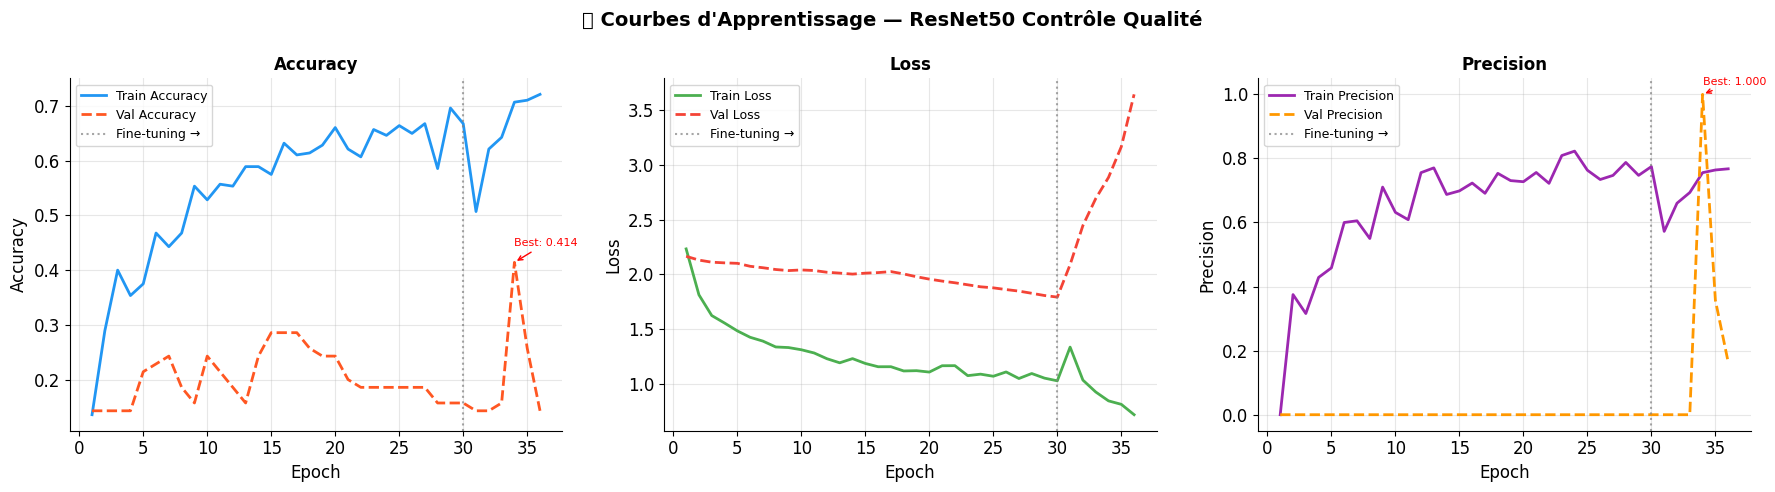

✅ Courbes sauvegardées dans Google Drive


In [ ]:
# ── Visualisation des courbes d'apprentissage ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📈 Courbes d\'Apprentissage — ResNet50 Contrôle Qualité', fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('accuracy',  'val_accuracy',  'Accuracy',   '#2196F3', '#FF5722'),
    ('loss',      'val_loss',      'Loss',        '#4CAF50', '#F44336'),
    ('precision', 'val_precision', 'Precision',   '#9C27B0', '#FF9800'),
]

for ax, (train_key, val_key, title, c_train, c_val) in zip(axes, metrics_to_plot):
    if train_key in full_history and val_key in full_history:
        epochs_range = range(1, len(full_history[train_key]) + 1)
        ax.plot(epochs_range, full_history[train_key], color=c_train,
                linewidth=2, label=f'Train {title}')
        ax.plot(epochs_range, full_history[val_key], color=c_val,
                linewidth=2, linestyle='--', label=f'Val {title}')
        # Marquer la séparation phase 1 / fine-tuning
        phase1_end = len(history.history['loss'])
        ax.axvline(phase1_end, color='gray', linestyle=':', alpha=0.7, label='Fine-tuning →')
        ax.set_title(f'{title}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        # Annoter le meilleur point
        if 'loss' not in train_key:
            best_idx = int(np.argmax(full_history[val_key]))
            best_val = full_history[val_key][best_idx]
            ax.annotate(f'Best: {best_val:.3f}',
                        xy=(best_idx + 1, best_val),
                        xytext=(best_idx + 1, best_val + 0.03),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        fontsize=8, color='red')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes sauvegardées dans Google Drive")


---
## 🧪 13.12 — Évaluation sur l'Ensemble de Validation

In [ ]:
# ── Évaluation globale sur l'ensemble de validation ──────────────────────────
val_gen.reset()
results = model.evaluate(val_gen, verbose=1)
metrics_names = model.metrics_names
print("\n📊 Résultats finaux (Validation) :")
for name, val in zip(metrics_names, results):
    icon = '🎯' if 'accuracy' in name else ('📉' if 'loss' in name else '📌')
    print(f"   {icon} {name:<15}: {val:.4f}")

# ── F1-Score macro ────────────────────────────────────────────────────────────
prec_idx  = metrics_names.index('precision') if 'precision' in metrics_names else None
rec_idx   = metrics_names.index('recall')    if 'recall'    in metrics_names else None
if prec_idx and rec_idx:
    p, r = results[prec_idx], results[rec_idx]
    f1   = 2 * p * r / (p + r + 1e-8)
    print(f"   🏆 F1-Score (macro)  : {f1:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.1429 - loss: 2.0885 - precision: 0.0000e+00 - recall: 0.0000e+00

📊 Résultats finaux (Validation) :
   📉 loss           : 2.0885
   📌 compile_metrics: 0.1429


---
## 🔢 13.13 — Matrice de Confusion & Rapport de Classification

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step

📋 Rapport de Classification :
                  precision    recall  f1-score   support

   ceramique_bon     0.0000    0.0000    0.0000        10
ceramique_defaut     0.1429    1.0000    0.2500        10
        bois_bon     0.0000    0.0000    0.0000        10
     bois_defaut     0.0000    0.0000    0.0000        10
      cuivre_bon     0.0000    0.0000    0.0000        10
   cuivre_defaut     0.0000    0.0000    0.0000        10
transport_defaut     0.0000    0.0000    0.0000        10

        accuracy                         0.1429        70
       macro avg     0.0204    0.1429    0.0357        70
    weighted avg     0.0204    0.1429    0.0357        70



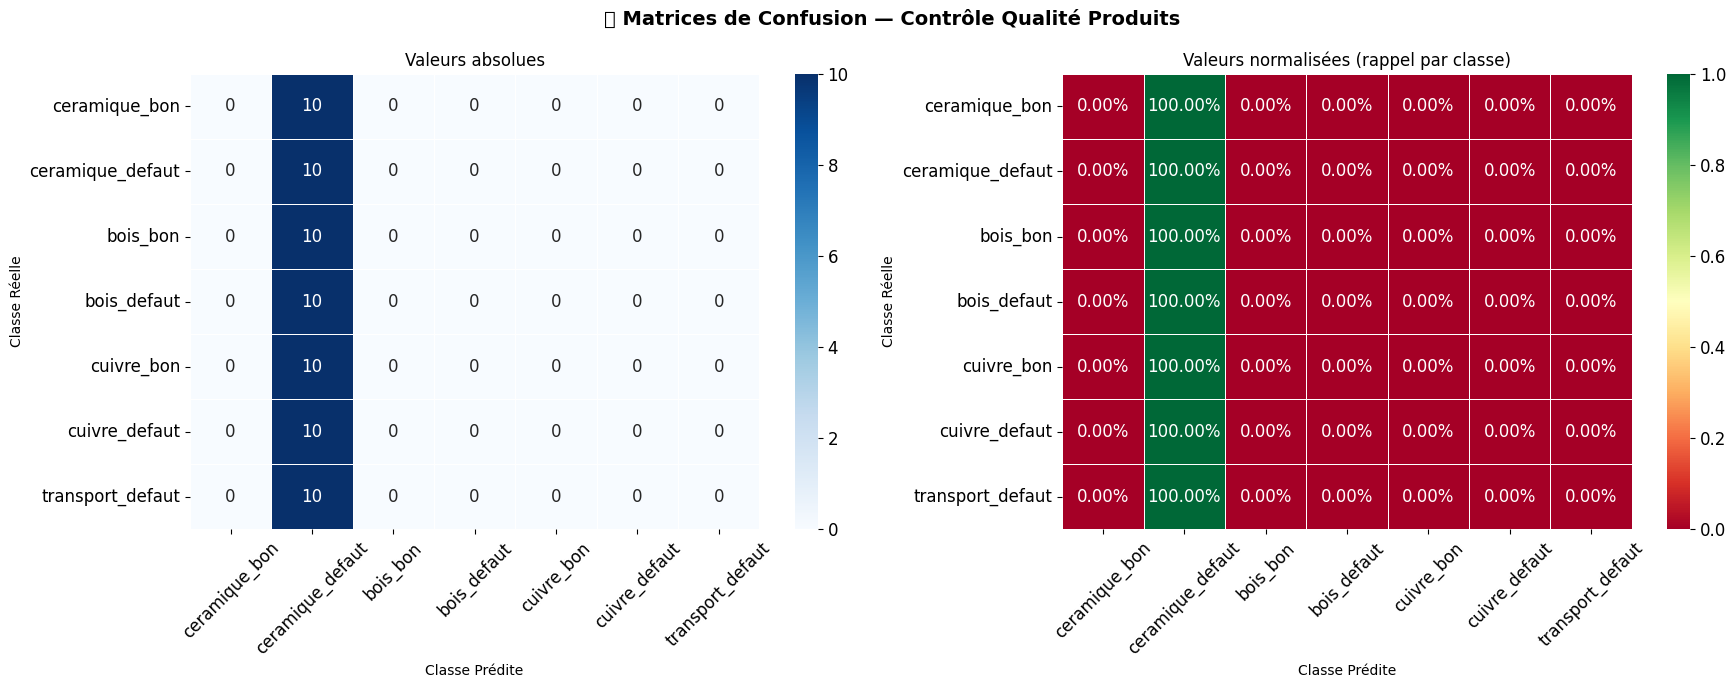

✅ Matrice de confusion sauvegardée dans Google Drive


In [ ]:
# ── Prédictions sur tout l'ensemble de validation ────────────────────────────
val_gen.reset()
y_pred_proba = model.predict(val_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = val_gen.classes

# ── Rapport de classification ─────────────────────────────────────────────────
print("\n📋 Rapport de Classification :")
report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print(report)

# ── Matrice de confusion annotée ─────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🔢 Matrices de Confusion — Contrôle Qualité Produits', fontsize=14, fontweight='bold')

# Brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Valeurs absolues', fontsize=12)
axes[0].set_xlabel('Classe Prédite', fontsize=10)
axes[0].set_ylabel('Classe Réelle', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalisée
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Valeurs normalisées (rappel par classe)', fontsize=12)
axes[1].set_xlabel('Classe Prédite', fontsize=10)
axes[1].set_ylabel('Classe Réelle', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrice de confusion sauvegardée dans Google Drive")


---
## 🔍 13.14 — Exemples de Prédictions sur des Images de Validation

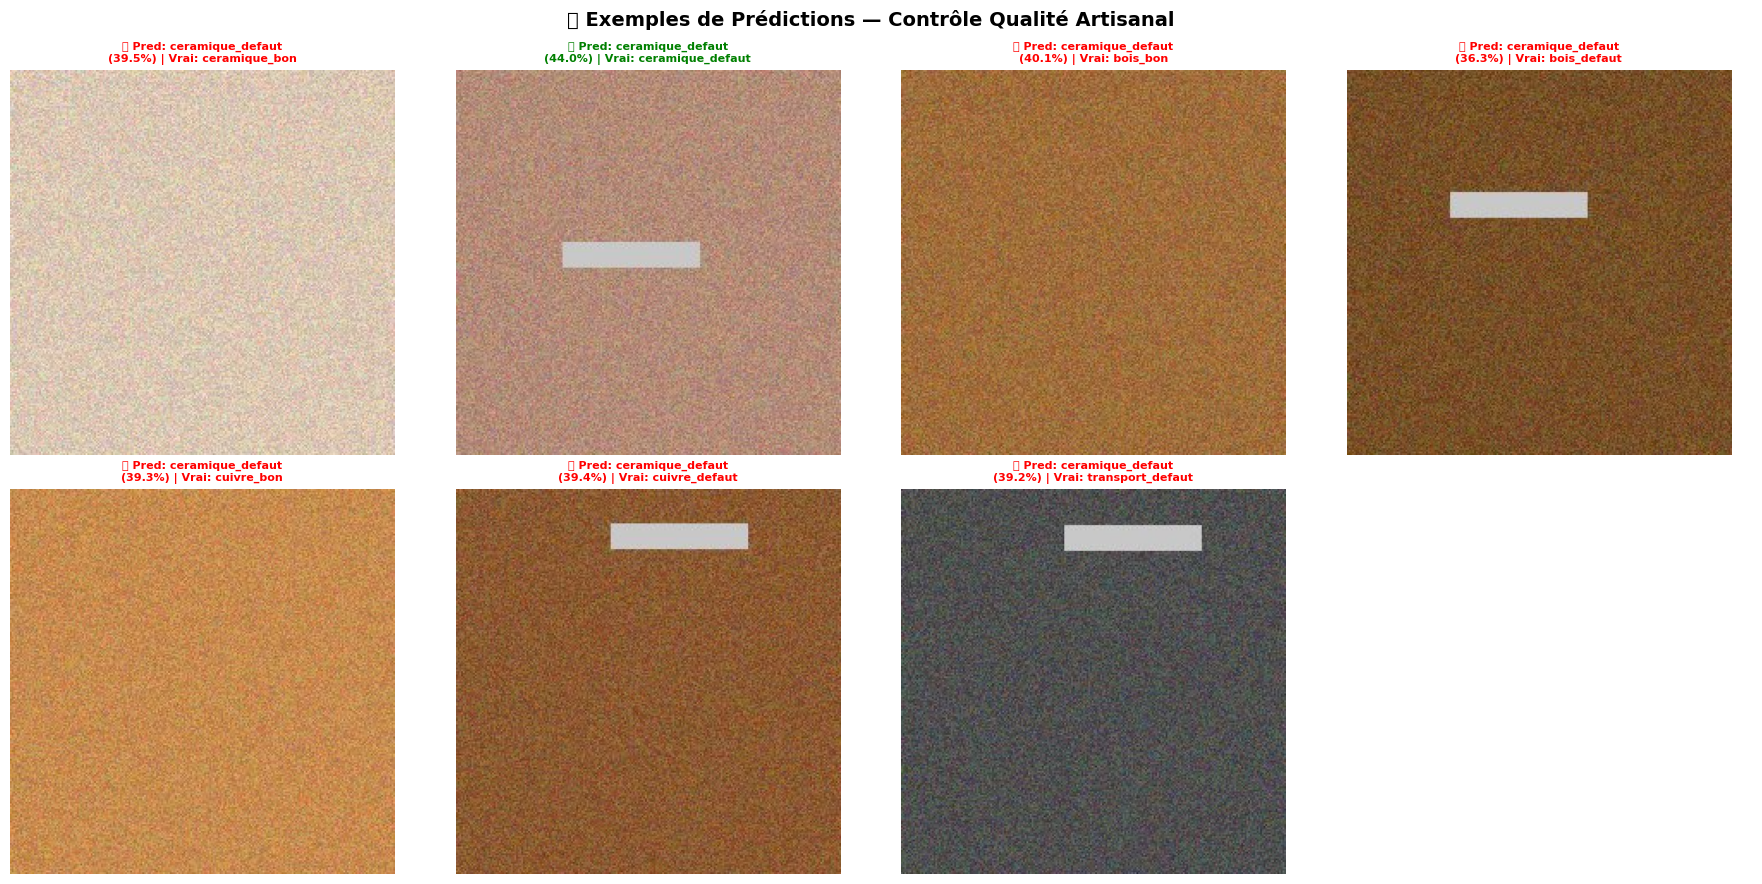

✅ Exemples de prédictions sauvegardés dans Google Drive


In [ ]:
# ── Affichage de prédictions sur des images de l'ensemble de validation ───────
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_single_image(img_path, model, classes, img_size=(224, 224)):
    """Prédit la classe d'une image et retourne (classe, confiance, proba_all)."""
    img     = load_img(img_path, target_size=img_size)
    arr     = img_to_array(img) / 255.0
    arr_exp = np.expand_dims(arr, axis=0)
    proba   = model.predict(arr_exp, verbose=0)[0]
    idx     = np.argmax(proba)
    return classes[idx], float(proba[idx]), proba

# ── Collecte d'images de validation ──────────────────────────────────────────
sample_images = []
for cls in CLASSES:
    folder = os.path.join(VAL_DIR, cls)
    imgs   = [os.path.join(folder, f) for f in os.listdir(folder)
              if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    if imgs:
        sample_images.append((random.choice(imgs), cls))

# ── Visualisation ─────────────────────────────────────────────────────────────
N_SHOW = min(len(sample_images), NUM_CLASSES)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('🔍 Exemples de Prédictions — Contrôle Qualité Artisanal', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
for i, (img_path, true_cls) in enumerate(sample_images[:N_SHOW]):
    pred_cls, confidence, proba = predict_single_image(img_path, model, CLASSES)
    correct = (pred_cls == true_cls)

    ax = axes_flat[i]
    img_disp = load_img(img_path, target_size=(224, 224))
    ax.imshow(img_disp)

    border_color = '#4CAF50' if correct else '#F44336'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    icon    = '✅' if correct else '❌'
    title   = f"{icon} Pred: {pred_cls}\n({confidence*100:.1f}%) | Vrai: {true_cls}"
    title_c = 'green' if correct else 'red'
    ax.set_title(title, fontsize=8, color=title_c, fontweight='bold')
    ax.axis('off')

# Masquer le dernier si impair
for j in range(N_SHOW, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_prediction_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Exemples de prédictions sauvegardés dans Google Drive")


---
## 📊 13.15 — Visualisation de la Distribution des Confiances

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


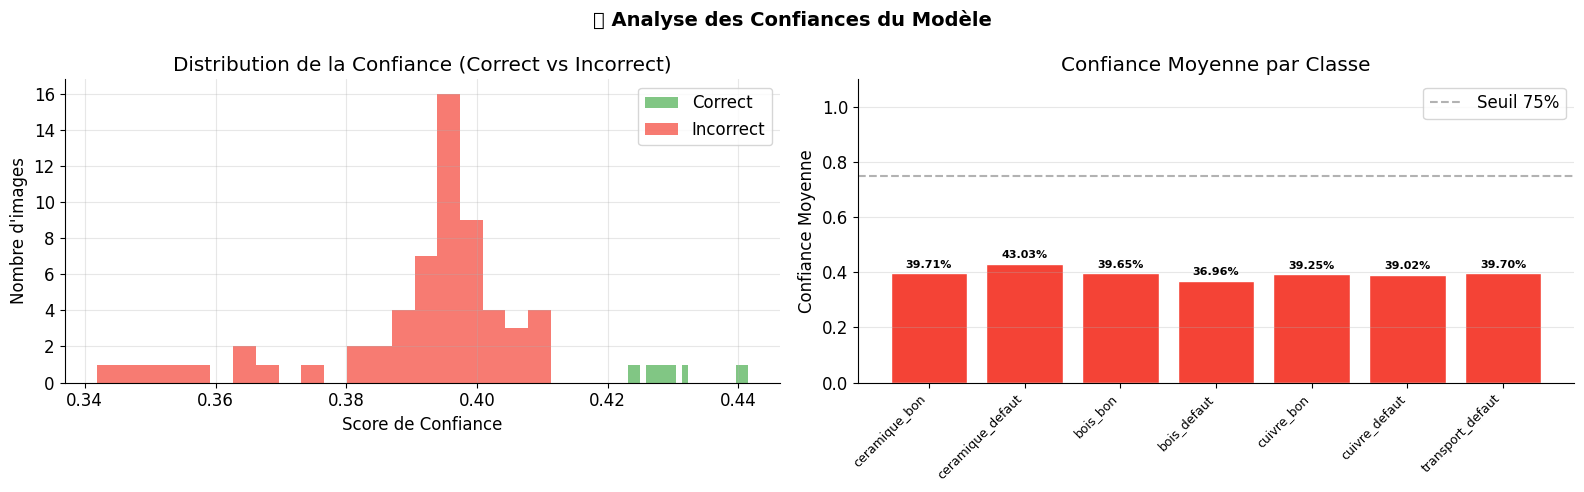

In [ ]:
# ── Distribution des scores de confiance par classe ──────────────────────────
val_gen.reset()
all_proba = model.predict(val_gen, verbose=1)
all_conf  = all_proba.max(axis=1)
all_pred  = all_proba.argmax(axis=1)
all_true  = val_gen.classes
is_correct = (all_pred == all_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📊 Analyse des Confiances du Modèle', fontsize=14, fontweight='bold')

# Distribution globale
axes[0].hist(all_conf[is_correct],  bins=20, alpha=0.7, color='#4CAF50', label='Correct')
axes[0].hist(all_conf[~is_correct], bins=20, alpha=0.7, color='#F44336', label='Incorrect')
axes[0].set_title('Distribution de la Confiance (Correct vs Incorrect)')
axes[0].set_xlabel('Score de Confiance')
axes[0].set_ylabel('Nombre d\'images')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confiance moyenne par classe
mean_conf_per_class = []
for i, cls in enumerate(CLASSES):
    mask = all_true == i
    if mask.sum() > 0:
        mean_conf_per_class.append(all_conf[mask].mean())
    else:
        mean_conf_per_class.append(0)

colors = ['#4CAF50' if c >= 0.75 else '#FF9800' if c >= 0.6 else '#F44336'
          for c in mean_conf_per_class]
bars = axes[1].bar(range(NUM_CLASSES), mean_conf_per_class, color=colors, edgecolor='white')
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Confiance Moyenne par Classe')
axes[1].set_ylabel('Confiance Moyenne')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.75, linestyle='--', color='gray', alpha=0.6, label='Seuil 75%')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, mean_conf_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2%}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_confidence_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 💾 13.16 — Sauvegarde du Modèle & Métadonnées (Déploiement Flask)

In [ ]:
# ── Sauvegarde finale du modèle au format .keras ──────────────────────────────
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'resnet50_quality_control_final.keras')
model.save(FINAL_MODEL_PATH)
print(f"✅ Modèle final sauvegardé : {FINAL_MODEL_PATH}")

# ── Sauvegarde des métadonnées pour le déploiement Flask ──────────────────────
metadata = {
    'classes'       : CLASSES,
    'num_classes'   : NUM_CLASSES,
    'img_size'      : IMG_SIZE,
    'batch_size'    : BATCH_SIZE,
    'epochs_phase1' : len(history.history['loss']),
    'epochs_ft'     : len(history_ft.history['loss']),
    'history'       : full_history,
    'best_val_acc'  : max(full_history['val_accuracy']),
    'model_path'    : FINAL_MODEL_PATH,
    'class_indices' : train_gen.class_indices,
}

META_PATH = os.path.join(MODEL_DIR, 'dl_model_metadata.pkl')
with open(META_PATH, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✅ Métadonnées sauvegardées : {META_PATH}")

# ── Résumé de déploiement ─────────────────────────────────────────────────────
print("\n🚀 Fichiers prêts pour le déploiement Flask :")
print(f"   📦 Modèle     : {FINAL_MODEL_PATH}")
print(f"   📋 Métadonnées: {META_PATH}")
print(f"\n📊 Performances finales :")
print(f"   🎯 Meilleure val_accuracy  : {metadata['best_val_acc']*100:.1f}%")
print(f"   📐 Taille d\'entrée image  : {IMG_SIZE}")
print(f"   🏷️  Classes ({NUM_CLASSES})     : {', '.join(CLASSES)}")


✅ Modèle final sauvegardé : /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_control_final.keras
✅ Métadonnées sauvegardées : /content/drive/MyDrive/ML_Ecommerce_DL/models/dl_model_metadata.pkl

🚀 Fichiers prêts pour le déploiement Flask :
   📦 Modèle     : /content/drive/MyDrive/ML_Ecommerce_DL/models/resnet50_quality_control_final.keras
   📋 Métadonnées: /content/drive/MyDrive/ML_Ecommerce_DL/models/dl_model_metadata.pkl

📊 Performances finales :
   🎯 Meilleure val_accuracy  : 41.4%
   📐 Taille d'entrée image  : (224, 224)
   🏷️  Classes (7)     : ceramique_bon, ceramique_defaut, bois_bon, bois_defaut, cuivre_bon, cuivre_defaut, transport_defaut


---
## 🏁 13.19 — Récapitulatif de la Section Deep Learning

In [ ]:
# ── Tableau récapitulatif de la section DL ────────────────────────────────────
import os

print("=" * 65)
print("🖼️  RÉCAPITULATIF — Deep Learning Contrôle Qualité Artisanal")
print("=" * 65)

print("\n📐 Architecture :")
print("   ├─ Backbone    : ResNet50 (ImageNet, include_top=False)")
print("   ├─ Tête        : GAP → Dense(512) → BN → Dropout(0.5) → Softmax(7)")
print("   ├─ Optimizer   : Adam (LR 1e-4 → 1e-5 fine-tuning)")
print("   └─ Loss        : Categorical Cross-Entropy")

print("\n🏷️  Classes :")
for i, cls in enumerate(CLASSES):
    icon = '⚠️' if 'defaut' in cls else '✅'
    print(f"   {i}: {icon} {cls}")

print("\n📊 Performances (validation) :")
best_val = max(full_history['val_accuracy'])
print(f"   🎯 Accuracy    : {best_val*100:.1f}%")
if 'val_precision' in full_history:
    print(f"   📌 Precision   : {max(full_history['val_precision'])*100:.1f}%")
if 'val_recall' in full_history:
    print(f"   📡 Recall      : {max(full_history['val_recall'])*100:.1f}%")
print(f"   🔄 Epochs      : {len(full_history['loss'])} (phase1 + fine-tuning)")

print("\n💾 Fichiers générés :")
files_to_check = [
    ('Modèle final (.keras)',  os.path.join(MODEL_DIR, 'resnet50_quality_control_final.keras')),
    ('Meilleur modèle phase1', os.path.join(MODEL_DIR, 'resnet50_quality_best.keras')),
    ('Meilleur modèle FT',     os.path.join(MODEL_DIR, 'resnet50_quality_finetune.keras')),
    ('Métadonnées (.pkl)',     os.path.join(MODEL_DIR, 'dl_model_metadata.pkl')),
    ('Courbes apprentissage',  os.path.join(OUTPUT_DIR, 'dl_learning_curves.png')),
    ('Matrice de confusion',   os.path.join(OUTPUT_DIR, 'dl_confusion_matrix.png')),
    ('Exemples prédictions',   os.path.join(OUTPUT_DIR, 'dl_prediction_examples.png')),
    ('Analyse confiance',      os.path.join(OUTPUT_DIR, 'dl_confidence_analysis.png')),
    ('Flask app.py',           os.path.join(OUTPUT_DIR, 'app_flask_quality.py')),
]
for label, path in files_to_check:
    exists = '✅' if os.path.exists(path) else '❌ (non généré)'
    size   = f" ({os.path.getsize(path)/1024:.0f} KB)" if os.path.exists(path) else ''
    print(f"   {exists} {label}{size}")

print("\n🚀 Utilisation en production :")
print("   1. Copier resnet50_quality_control_final.keras + dl_model_metadata.pkl")
print("   2. Déployer avec app_flask_quality.py")
print("   3. Appeler POST /predict avec l'image en multipart")
print("=" * 65)
print("✅ Section Deep Learning complète !")


🖼️  RÉCAPITULATIF — Deep Learning Contrôle Qualité Artisanal

📐 Architecture :
   ├─ Backbone    : ResNet50 (ImageNet, include_top=False)
   ├─ Tête        : GAP → Dense(512) → BN → Dropout(0.5) → Softmax(7)
   ├─ Optimizer   : Adam (LR 1e-4 → 1e-5 fine-tuning)
   └─ Loss        : Categorical Cross-Entropy

🏷️  Classes :
   0: ✅ ceramique_bon
   1: ⚠️ ceramique_defaut
   2: ✅ bois_bon
   3: ⚠️ bois_defaut
   4: ✅ cuivre_bon
   5: ⚠️ cuivre_defaut
   6: ⚠️ transport_defaut

📊 Performances (validation) :
   🎯 Accuracy    : 41.4%
   📌 Precision   : 100.0%
   📡 Recall      : 14.3%
   🔄 Epochs      : 36 (phase1 + fine-tuning)

💾 Fichiers générés :
   ✅ Modèle final (.keras) (174939 KB)
   ✅ Meilleur modèle phase1 (105146 KB)
   ✅ Meilleur modèle FT (174939 KB)
   ✅ Métadonnées (.pkl) (3 KB)
   ✅ Courbes apprentissage (171 KB)
   ✅ Matrice de confusion (176 KB)
   ✅ Exemples prédictions (3734 KB)
   ✅ Analyse confiance (124 KB)
   ✅ Flask app.py (2 KB)

🚀 Utilisation en production :
   1. Co